<a href="https://colab.research.google.com/github/SantiagoEzequielDrelewicz/TP-LMC/blob/main/TP_LMCAG_Notebook_troncal_general_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !git clone https://github.com/SantiagoEzequielDrelewicz/TP-LMC.git
    %cd TP-LMC
    # !pip install -r requirements.txt

In [72]:
# !pip install -r requirements.txt # descomentar y ejecutar si se corre localmente y no se usa un entorno virtual.

In [110]:
import os
from pathlib import Path
import zipfile # para descomprimir los datasets

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Carga de los datasets

In [73]:
def cargar_dataset(letra: str) -> pd.DataFrame:
    """Descomprime el dataset correspondiente a la letra dada."""
    with zipfile.ZipFile(f"datos/crudos/datasets.zip", "r") as z:
        with z.open(f"datasets/Dataset_{letra}.csv") as f:
            df = pd.read_csv(f, sep=";")
    return df

In [74]:
df_A = cargar_dataset("A")
df_A

C:\Users\sandr\AppData\Local\Temp\ipykernel_17988\3506033332.py:5: DtypeWarning: Columns (0: FECHA BAJA) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, sep=";")


,ID,PLAN,GRUPPO,TARIFA DETALLE,FECHA ACTIVACION,TOTAL ACTIVA,FECHA LETT ANT,FECHA LETT ACT,FECHA BAJA,DIAS LEIDOS,...,FACTOR ESTACIONAL,ENERGIA MEDIDORES,CONSUMO ESTIMADO,CONSUMO TOTAL FINAL,REFERENCIA,REAL MES CALCULADO,REAL ACUMULADO ANO,TOTAL BALANCE ANO,AJUSTE,ENERGIA ENTREGADA
0,9,7,T1,T1-R,24/9/1995,895.0,22/8/2025,22/10/2025,NaN,61.0,...,"0,951431459",0.0,419.0,"418,7858144",202511,0,7804,7997,0,"418,7858144"
1,24,7,T1,T1-R,24/9/1995,1254.0,22/8/2025,22/10/2025,NaN,61.0,...,"0,951431459",0.0,587.0,"586,7680573",202511,0,4575,4345,0,"586,7680573"
2,229,7,T1,T1-R,24/9/1995,953.0,22/8/2025,22/10/2025,NaN,61.0,...,"0,951431459",0.0,446.0,"445,9250069",202511,0,6395,6245,0,"445,9250069"
3,302,7,T1,T1-R,24/9/1995,1239.0,22/8/2025,22/10/2025,NaN,61.0,...,"0,951431459",0.0,580.0,"579,7493007",202511,0,5586,5639,0,"579,7493007"
4,361,7,T1,T1-R,24/9/1995,1233.0,22/8/2025,22/10/2025,NaN,61.0,...,"0,951431459",0.0,577.0,"576,941798",202511,0,5135,5085,0,"576,941798"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177865,4603,7,T1,T1-G,24/9/1995,1275.0,22/10/2025,2/12/2025,NaN,41.0,...,"1,287038217",1161.0,0.0,"1222,883856",202512,987,13901,13989,-88,"1134,731648"
177866,7120,7,T1,T1-G,24/9/1995,600.0,22/10/2025,2/12/2025,NaN,41.0,...,"1,287038217",546.0,0.0,"575,4747556",202512,400,4424,4324,100,"675,0047745"
177867,2694,7,T1,T1-G,24/9/1995,1661.0,22/10/2025,2/12/2025,NaN,41.0,...,"1,287038217",1512.0,0.0,"1593,105948",202512,1436,15233,15676,-443,"1149,684167"
177868,9194,7,T1,T1-G,24/9/1995,4320.0,22/10/2025,2/12/2025,NaN,41.0,...,"1,287038217",3933.0,0.0,"4143,41824",202512,2986,29232,28746,485,"4628,542404"


## Union de los datasets

In [75]:
def cargar_dataset_completo() -> pd.DataFrame:
    """Concatena los datasets A, B, C y D."""
    df_completo = pd.DataFrame()
    for letra in ["A", "B", "C", "D"]:
        df_letra =  cargar_dataset(letra)
        df_completo = pd.concat([df_completo, df_letra])
    return df_completo

In [76]:
df_completo = cargar_dataset_completo()
df_completo

C:\Users\sandr\AppData\Local\Temp\ipykernel_17988\3506033332.py:5: DtypeWarning: Columns (0: FECHA BAJA) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, sep=";")
C:\Users\sandr\AppData\Local\Temp\ipykernel_17988\3506033332.py:5: DtypeWarning: Columns (0: FECHA BAJA) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, sep=";")
C:\Users\sandr\AppData\Local\Temp\ipykernel_17988\3506033332.py:5: DtypeWarning: Columns (0: FECHA BAJA) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, sep=";")
C:\Users\sandr\AppData\Local\Temp\ipykernel_17988\3506033332.py:5: DtypeWarning: Columns (0: FECHA BAJA) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, sep=";")


,ID,PLAN,GRUPPO,TARIFA DETALLE,FECHA ACTIVACION,TOTAL ACTIVA,FECHA LETT ANT,FECHA LETT ACT,FECHA BAJA,DIAS LEIDOS,...,FACTOR ESTACIONAL,ENERGIA MEDIDORES,CONSUMO ESTIMADO,CONSUMO TOTAL FINAL,REFERENCIA,REAL MES CALCULADO,REAL ACUMULADO ANO,TOTAL BALANCE ANO,AJUSTE,ENERGIA ENTREGADA
0,9,7,T1,T1-R,24/9/1995,895.0,22/8/2025,22/10/2025,NaN,61.0,...,"0,951431459",0.0,419.0,"418,7858144",202511,0,7804,7997,0,"418,7858144"
1,24,7,T1,T1-R,24/9/1995,1254.0,22/8/2025,22/10/2025,NaN,61.0,...,"0,951431459",0.0,587.0,"586,7680573",202511,0,4575,4345,0,"586,7680573"
2,229,7,T1,T1-R,24/9/1995,953.0,22/8/2025,22/10/2025,NaN,61.0,...,"0,951431459",0.0,446.0,"445,9250069",202511,0,6395,6245,0,"445,9250069"
3,302,7,T1,T1-R,24/9/1995,1239.0,22/8/2025,22/10/2025,NaN,61.0,...,"0,951431459",0.0,580.0,"579,7493007",202511,0,5586,5639,0,"579,7493007"
4,361,7,T1,T1-R,24/9/1995,1233.0,22/8/2025,22/10/2025,NaN,61.0,...,"0,951431459",0.0,577.0,"576,941798",202511,0,5135,5085,0,"576,941798"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177889,38255,64,T1,T1-R,2/7/2003,1788.0,18/7/2025,17/9/2025,14/11/2025,61.0,...,"0,805124192",0.0,330.0,"330,3912914",202511,498,6764,8133,-1369,"-1038,670412"
177890,38255,64,T1,T1-R,2/7/2003,1788.0,18/7/2025,17/9/2025,14/11/2025,61.0,...,"0,805122685",0.0,330.0,"330,3906729",202511,498,6764,8133,-1369,"-1038,670412"
177891,38802,46,T1,T1-R,14/9/2002,1499.0,18/6/2025,18/8/2025,17/10/2025,61.0,...,"0,703439837",0.0,294.0,"293,8648748",202510,442,5462,6597,-1134,"-840,6172079"
177892,39734,64,T1,T1-R,26/5/2003,1486.0,17/7/2025,16/9/2025,14/11/2025,61.0,...,"0,800373321",0.0,273.0,"272,9666652",202511,390,4906,6058,-1151,"-878,2512804"


In [77]:
df_completo.info()

<class 'pandas.DataFrame'>
Index: 711829 entries, 0 to 177893
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ID                              711829 non-null  int64  
 1   PLAN                            711829 non-null  int64  
 2   GRUPPO                          711829 non-null  str    
 3   TARIFA DETALLE                  711829 non-null  str    
 4   FECHA ACTIVACION                711829 non-null  str    
 5   TOTAL ACTIVA                    710728 non-null  float64
 6   FECHA LETT ANT                  710728 non-null  str    
 7   FECHA LETT ACT                  710728 non-null  str    
 8   FECHA BAJA                      4215 non-null    str    
 9   DIAS LEIDOS                     710728 non-null  float64
 10  PROMEDIO CONSUMO                710728 non-null  str    
 11  DIAS LEIDOS MES                 711829 non-null  int64  
 12  DIAS ESTIMAR                    

## **Columnas a utilizar**
- ID: n° de cliente
- FECHA ACTIVACION: fecha de alta del cliente
- TOTAL ACTIVA consumo de energia (kWh) entre FECHA LETT ANT y FECHA LETT ACT
- FECHA LETT ANT: fecha de la penultima lectura
- FECHA LETT ACT: fecha de la última lectura
- FECHA BAJA: fecha de baja del cliente
- DIAS LEIDOS: dias entre FECHA LETT ANT y FECHA LETT ACT
- PROMEDIO CONSUMO = TOTAL ACTIVA / DIAS LEIDOS
- DIAS LEIDOS MES: dias de lectura en el mes de REFERENCIA
- DIAS ESTIMAR = dias entre max(FECHA LETT ACT, fecha correspondiente a DIAS LEIDOS MES) y ultimo dia del mes de REFERENCIA
- CONSUMO LEIDO = cosumo de energía leido en el mes de REFERENCIA
- DEMANDA PERIODO LEIDO = demanda total comprendida entre FECHA LETT ANT y FECHA LETT ACT
- DEMANDA PERIODO DIAS MEDIDORES: demanda total entre max(FECHA LETT ACT, la fecha correspondiente al día DIAS LEIDOS MES) y el último día del mes de REFERENCIA
- FACTOR ESTACIONAL = $\frac{
    \frac{\text{DEMANDA PERIODO DIAS MEDIDORES}}
         {\text{DIAS ESTIMAR}}
  }{
    \frac{\text{DEMANDA PERIODO LEIDO}}
         {\text{DIAS LEIDOS}}
  }$
- ENERGIA MEDIDORES:
  ```
  Si (DIAS LEIDOS > 0 ) entonces
    ENERGIA MEDIDORES = FACTOR ESTACIONAL × PROMEDIO CONSUMO × DIAS ESTIMAR,
  sino
    ENERGIA MEDIDORES = 0
    
  ```
- CONSUMO ESTIMADO:
  ```
  Si (DIAS LEIDOS = 0 ) entonces
    CONSUMO ESTIMADO = FACTOR ESTACIONAL × PROMEDIO CONSUMO × DIAS ESTIMAR,
  sino
    CONSUMO ESTIMADO = 0
    
  ```
- CONSUMO TOTAL FINAL = ENERGIA MEDIDORES + CONSUMO ESTIMADO + CONSUMO LEIDO

In [10]:
COLUMNAS_RELEVANTES = [
    "ID",
    "FECHA ACTIVACION",
    "TOTAL ACTIVA",
    "FECHA LETT ANT",
    "FECHA LETT ACT",
    "FECHA BAJA",
    "DIAS LEIDOS",
    "PROMEDIO CONSUMO",
    "DIAS LEIDOS MES",
    "DIAS ESTIMAR",
    "CONSUMO LEIDO",
    "DEMANDA PERIODO LEIDO",
    "DEMANDA PERIODO DIAS MEDIDORES",
    "FACTOR ESTACIONAL",
    "ENERGIA MEDIDORES",
    "CONSUMO ESTIMADO",
    "CONSUMO TOTAL FINAL",
    "REFERENCIA",
]

# Modelo

$$
c(t) = B + \beta_c \cdot HDD(t) + \beta_f \cdot CDD(t)
$$

- $B$: consumo base del cliente  
- $HDD(t)$: frío instantáneo  
- $CDD(t)$: calor instantáneo  

---

$$
\beta_f = \frac{\partial c}{\partial HDD(t)}
$$

$$
\beta_c = \frac{\partial c}{\partial CDD(t)}
$$

---

$$
C\Big|_{t_0}^{t_1} = \int_{t_0}^{t_1} c(t)\,dt
$$

$$
C = \int_{t_0}^{t_1}
\left(
B + \beta_f \cdot HDD(t) + \beta_c \cdot CDD(t)
\right)\,dt
$$

$$
C =
B \cdot \Delta t
+
\beta_f \cdot \int_{t_0}^{t_1} HDD(t)\,dt
+
\beta_c \cdot \int_{t_0}^{t_1} CDD(t)\,dt
$$

---

$$
B_{\text{cliente}}
=
\min\left(
[C\!ONSUMO\ TOTAL\ FINAL]_{\text{cliente-2025}}
\right)
$$

---

$$
C_{\text{estimado}}
=
\int_{t_0}^{t_1}
\left(
B + \beta_c \cdot HDD(t) + \beta_f \cdot CDD(t)
\right)\,dt
$$

---

$$
\frac{\partial C(\text{mes})}{\partial HDD(\text{mes})}
=
\beta_c
$$

$$
\frac{\partial C(\text{mes})}{\partial CDD(\text{mes})}
=
\beta_f
$$

In [11]:
df_completo.describe()

,ID,PLAN,TOTAL ACTIVA,DIAS LEIDOS,DIAS LEIDOS MES,DIAS ESTIMAR,CONSUMO LEIDO,DEMANDA PERIODO LEIDO,DEMANDA PERIODO DIAS MEDIDORES,ENERGIA MEDIDORES,CONSUMO ESTIMADO,REFERENCIA,REAL MES CALCULADO,REAL ACUMULADO ANO,TOTAL BALANCE ANO,AJUSTE
count,711829.000000,711829.000000,710728.000000,710728.000000,711829.000000,711829.000000,711829.000000,7.107280e+05,6.979730e+05,697973.000000,699074.000000,711829.000000,711829.000000,711829.000000,711829.000000,711829.000000
mean,19999.992972,54.148267,1202.000477,59.519424,7.125166,23.205582,143.444646,3.470958e+09,1.400490e+09,186.230992,301.001282,202507.146317,297.542633,3473.925160,3476.643740,-2.745919
std,11545.129564,20.617158,1296.758233,7.389018,9.600803,9.648897,313.594829,6.071522e+08,5.795530e+08,423.157758,563.931931,3.287131,556.905010,4528.935099,4568.297992,493.056657
min,1.000000,6.000000,1.000000,5.000000,0.000000,0.000000,0.000000,2.544481e+08,0.000000e+00,0.000000,0.000000,202501.000000,0.000000,0.000000,0.000000,-28539.000000
25%,10004.000000,50.000000,692.000000,59.000000,0.000000,18.000000,0.000000,3.096786e+09,1.023775e+09,0.000000,0.000000,202505.000000,0.000000,1387.000000,1296.000000,0.000000
50%,20001.000000,59.000000,937.000000,61.000000,2.000000,28.000000,21.000000,3.509140e+09,1.538967e+09,20.000000,0.000000,202507.000000,0.000000,2924.000000,2893.000000,0.000000
75%,29997.000000,68.000000,1335.000000,62.000000,13.000000,30.000000,197.000000,3.894814e+09,1.850257e+09,284.000000,481.000000,202510.000000,461.000000,4421.000000,4475.000000,0.000000
max,40000.000000,79.000000,96000.000000,423.000000,31.000000,31.000000,40353.000000,2.446803e+10,2.161943e+09,40610.000000,44976.000000,202512.000000,49600.000000,405902.000000,418068.000000,95280.000000


# Limpieza del dataset

## Valores nulos

In [12]:
# Información general
print("Shape del dataframe:")
print(df_completo.shape)

print("\nCantidad total de valores:")
print(df_completo.size)

print("\nCantidad total de nulos:")
print(df_completo.isnull().sum().sum())

print("\nPorcentaje total de nulos:")
print(round(df_completo.isnull().sum().sum() / df_completo.size * 100, 2), "%")

# Nulos por columna
nulos_columna = pd.DataFrame({
    "cant_nulos": df_completo.isnull().sum(),
    "porcentaje_nulos": round(df_completo.isnull().mean() * 100, 2)
})

# Ordenar de mayor a menor
nulos_columna = nulos_columna.sort_values(by="cant_nulos", ascending=False)

print("\nNulos por columna:")
display(nulos_columna)

# Filas con al menos un nulo
filas_con_nulos = df_completo.isnull().any(axis=1).sum()

print("\nCantidad de filas con al menos un nulo:")
print(filas_con_nulos)

print("\nPorcentaje de filas con al menos un nulo:")
print(round(filas_con_nulos / len(df_completo) * 100, 2), "%")

Shape del dataframe:
(711829, 26)

Cantidad total de valores:
18507554

Cantidad total de nulos:
768543

Porcentaje total de nulos:
4.15 %

Nulos por columna:


,cant_nulos,porcentaje_nulos
FECHA BAJA,707614,99.41
FACTOR ESTACIONAL,13856,1.95
ENERGIA MEDIDORES,13856,1.95
DEMANDA PERIODO DIAS MEDIDORES,13856,1.95
CONSUMO ESTIMADO,12755,1.79
DEMANDA PERIODO LEIDO,1101,0.15
DIAS LEIDOS,1101,0.15
FECHA LETT ACT,1101,0.15
FECHA LETT ANT,1101,0.15
TOTAL ACTIVA,1101,0.15



Cantidad de filas con al menos un nulo:
707614

Porcentaje de filas con al menos un nulo:
99.41 %


## FECHA DE BAJA
Dropeamos las filas que tenga valores no nulos de fecha de baja y la eliminamos para el análisis. Y ahora si podemos eliminar el resto de las filas que tienen valores nulos

Son todos datos de 2025, entonces solo nos importan los meses

## Errores de escritura:
PROMEDIO CONSUMO, FACTOR ESTACIONAL y CONSUMO TOTAL FINAL tienen una coma en vez de punto lo cual los convierte a tipo object.

In [13]:
def coma_num_to_float(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    for col in cols:
      df[col] = df[col].astype(str).str.replace(",", ".").astype(float)
    return df[cols]

## REFERENCIA
El periodo de refencia Está como int y todos sus datos corresponden a 2025, así que solo nos importa su mes

In [14]:
df_completo["REFERENCIA"].astype(str).str[:4].unique()

<ArrowStringArray>
['2025']
Length: 1, dtype: str

In [103]:
RUTA_GUARDADO = "datos/procesados/datos_limpios.csv.gz"

def limpiar_dataset(
    df: pd.DataFrame, *, 
    sin_bajas: bool = True, 
    filtrar_columnas: bool = False, 
    sacar_nulos: bool = True,
    sacar_duplicados: bool = False,
) -> pd.DataFrame:
    """Realiza la limpieza del dataset completo."""
    df_limpio = df.copy()

    # Filtrar columnas relevantes
    if filtrar_columnas:
        df_limpio = df_limpio[COLUMNAS_RELEVANTES]

    # Filtrar/eliminar filas con fecha de baja no nula y luego eliminarla, ya que no aporta información relevante para el análisis
    if sin_bajas:
        df_limpio = df_limpio[df_limpio["FECHA BAJA"].isnull()].reset_index(drop=True).drop(columns=["FECHA BAJA"])

    # Eliminar filas con valores nulos
    if sacar_nulos:
        df_limpio.dropna(inplace=True)

    # Eliminar duplicados
    if sacar_duplicados:
        df_limpio.drop_duplicates(inplace=True)

    # Convertir columnas con números en formato de coma a float
    columnas_con_coma_num = ["PROMEDIO CONSUMO", "FACTOR ESTACIONAL", "CONSUMO TOTAL FINAL"]
    df_limpio[columnas_con_coma_num] = coma_num_to_float(df_limpio, columnas_con_coma_num)

    # Extraer el mes de la columna REFERENCIA y convertirlo a int
    df_limpio["REFERENCIA"] = df_limpio["REFERENCIA"].astype(str).str[4:6].astype(int)

    return df_limpio

In [95]:
df_limpio = limpiar_dataset(df_completo)
df_limpio

,ID,PLAN,GRUPPO,TARIFA DETALLE,FECHA ACTIVACION,TOTAL ACTIVA,FECHA LETT ANT,FECHA LETT ACT,FECHA BAJA,DIAS LEIDOS,...,FACTOR ESTACIONAL,ENERGIA MEDIDORES,CONSUMO ESTIMADO,CONSUMO TOTAL FINAL,REFERENCIA,REAL MES CALCULADO,REAL ACUMULADO ANO,TOTAL BALANCE ANO,AJUSTE,ENERGIA ENTREGADA
0,9,7,T1,T1-R,24/9/1995,895.0,22/8/2025,22/10/2025,NaN,61.0,...,0.951431,0.0,419.0,418.785814,11,0,7804,7997,0,"418,7858144"
1,24,7,T1,T1-R,24/9/1995,1254.0,22/8/2025,22/10/2025,NaN,61.0,...,0.951431,0.0,587.0,586.768057,11,0,4575,4345,0,"586,7680573"
2,229,7,T1,T1-R,24/9/1995,953.0,22/8/2025,22/10/2025,NaN,61.0,...,0.951431,0.0,446.0,445.925007,11,0,6395,6245,0,"445,9250069"
3,302,7,T1,T1-R,24/9/1995,1239.0,22/8/2025,22/10/2025,NaN,61.0,...,0.951431,0.0,580.0,579.749301,11,0,5586,5639,0,"579,7493007"
4,361,7,T1,T1-R,24/9/1995,1233.0,22/8/2025,22/10/2025,NaN,61.0,...,0.951431,0.0,577.0,576.941798,11,0,5135,5085,0,"576,941798"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177889,38255,64,T1,T1-R,2/7/2003,1788.0,18/7/2025,17/9/2025,14/11/2025,61.0,...,0.805124,0.0,330.0,330.391291,11,498,6764,8133,-1369,"-1038,670412"
177890,38255,64,T1,T1-R,2/7/2003,1788.0,18/7/2025,17/9/2025,14/11/2025,61.0,...,0.805123,0.0,330.0,330.390673,11,498,6764,8133,-1369,"-1038,670412"
177891,38802,46,T1,T1-R,14/9/2002,1499.0,18/6/2025,18/8/2025,17/10/2025,61.0,...,0.703440,0.0,294.0,293.864875,10,442,5462,6597,-1134,"-840,6172079"
177892,39734,64,T1,T1-R,26/5/2003,1486.0,17/7/2025,16/9/2025,14/11/2025,61.0,...,0.800373,0.0,273.0,272.966665,11,390,4906,6058,-1151,"-878,2512804"


# Cargar dataset limpio

In [96]:
def cargar_dataset_limpio(guardar: bool = False) -> pd.DataFrame:
    """Carga el dataset completo y limpio."""
    # chequear si ya existe el dataset limpio guardado, sino limpiarlo y guardarlo
    if os.path.exists(RUTA_GUARDADO):
        print("Cargando dataset limpio desde el archivo guardado...")
        df = pd.read_csv(RUTA_GUARDADO)
    else:
        df_completo = cargar_dataset_completo()
        df = limpiar_dataset(df_completo)

        if guardar:
            df.to_csv(RUTA_GUARDADO, index=False, compression="gzip")
            print(f"Dataset limpio guardado en {RUTA_GUARDADO}")
            
    return df

In [97]:
df = cargar_dataset_limpio()
df

Cargando dataset limpio desde el archivo guardado...


,ID,PLAN,GRUPPO,TARIFA DETALLE,FECHA ACTIVACION,TOTAL ACTIVA,FECHA LETT ANT,FECHA LETT ACT,DIAS LEIDOS,PROMEDIO CONSUMO,...,FACTOR ESTACIONAL,ENERGIA MEDIDORES,CONSUMO ESTIMADO,CONSUMO TOTAL FINAL,REFERENCIA,REAL MES CALCULADO,REAL ACUMULADO ANO,TOTAL BALANCE ANO,AJUSTE,ENERGIA ENTREGADA
0,9,7,T1,T1-R,24/9/1995,895.0,22/8/2025,22/10/2025,61.0,14.672131,...,0.951431,0.0,419.0,418.785814,11,0,7804,7997,0,"418,7858144"
1,24,7,T1,T1-R,24/9/1995,1254.0,22/8/2025,22/10/2025,61.0,20.557377,...,0.951431,0.0,587.0,586.768057,11,0,4575,4345,0,"586,7680573"
2,229,7,T1,T1-R,24/9/1995,953.0,22/8/2025,22/10/2025,61.0,15.622951,...,0.951431,0.0,446.0,445.925007,11,0,6395,6245,0,"445,9250069"
3,302,7,T1,T1-R,24/9/1995,1239.0,22/8/2025,22/10/2025,61.0,20.311475,...,0.951431,0.0,580.0,579.749301,11,0,5586,5639,0,"579,7493007"
4,361,7,T1,T1-R,24/9/1995,1233.0,22/8/2025,22/10/2025,61.0,20.213115,...,0.951431,0.0,577.0,576.941798,11,0,5135,5085,0,"576,941798"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
693753,32713,7,T1,T1-G,24/9/1995,3372.0,22/10/2025,2/12/2025,41.0,82.243902,...,1.287038,3070.0,0.0,3234.168126,12,2469,24085,24008,77,"3311,380497"
693754,34749,7,T1,T1-G,24/9/1995,872.0,22/10/2025,2/12/2025,41.0,21.268293,...,1.287038,794.0,0.0,836.356645,12,587,5939,5806,133,"969,1322582"
693755,37589,7,T1,T1-G,24/9/1995,550.0,22/10/2025,2/12/2025,41.0,13.414634,...,1.287038,501.0,0.0,527.518526,12,434,5202,5257,-55,"472,5714829"
693756,38053,7,T1,T1-G,24/9/1995,765.0,22/10/2025,2/12/2025,41.0,18.658537,...,1.287038,696.0,0.0,733.730313,12,578,6644,6665,-22,"712,0904052"


# Calculo de B_cliente

In [19]:
b_cliente = df.groupby("ID")["CONSUMO TOTAL FINAL"].min()
b_cliente

ID
1         555.862177
2         401.663574
3         367.176171
4         399.816227
5        5618.556927
            ...     
39996      77.148421
39997     196.313654
39998     265.959060
39999     349.664054
40000     231.298116
Name: CONSUMO TOTAL FINAL, Length: 40000, dtype: float64

# CCD y HDD

In [82]:
RUTA_TEMPERATURAS_X_ANIO = "datos/crudos/temperaturas"
DIR_TEMPERATURAS_PROCESADAS = "datos/procesados/temperaturas/"

def cargar_temperaturas(año: int, guardar: bool = False) -> pd.DataFrame:
    df_temperaturas = pd.DataFrame()
    ruta_zip = Path(RUTA_TEMPERATURAS_X_ANIO) / f"{año}.zip"

    with zipfile.ZipFile(ruta_zip) as z:
        archivos = sorted(
            [f for f in z.namelist() if f.endswith(".csv")]
        )

        for archivo in archivos:

            # TempSMN_20260101.csv -> 20260101
            fecha = archivo.replace(".csv", "").split("_")[1]

            with z.open(archivo) as f:
                df = pd.read_csv(f, sep=";")

            df = df.rename(columns={
                df.columns[0]: "hora",
                df.columns[1]: "temperatura"
            })

            df = df[["hora", "temperatura"]]
            df["fecha"] = pd.to_datetime(fecha, format="%Y%m%d")

            df_temperaturas = pd.concat([df_temperaturas, df], ignore_index=True)

    # eliminar datos de otros años por si hay
    df_temperaturas = df_temperaturas[df_temperaturas["fecha"].dt.year == año].reset_index(drop=True)

    nombre_archivo_guardado = DIR_TEMPERATURAS_PROCESADAS + f"temperaturas_{año}.csv.gz"
    if guardar and not os.path.exists(nombre_archivo_guardado):
        df_temperaturas.to_csv(nombre_archivo_guardado, index=False, compression="gzip")

    return df_temperaturas

In [83]:
df_temperaturas_2025 = cargar_temperaturas(2025, guardar=True)
df_temperaturas_2025

,hora,temperatura,fecha
0,1,24.7,2025-01-01
1,2,24.6,2025-01-01
2,3,25.8,2025-01-01
3,4,24.4,2025-01-01
4,5,24.0,2025-01-01
...,...,...,...
8755,20,34.7,2025-12-31
8756,21,33.4,2025-12-31
8757,22,32.2,2025-12-31
8758,23,31.9,2025-12-31


Hacemos la función completa para calcular los hdd y cdd de una

In [84]:
def calcular_hdd_cdd_mensual(año: int, Tc: float = 20) -> pd.DataFrame:
    nombre_archivo = DIR_TEMPERATURAS_PROCESADAS + f"temperaturas_{año}.csv.gz"
    if not os.path.exists(nombre_archivo):
        df_temperaturas = cargar_temperaturas(año)
    else:
        df_temperaturas = pd.read_csv(nombre_archivo, compression="gzip")

    # Calcular el maximo entre temperatura - Tc y 0 para cada fila
    # para obtener el HDD y el CDD con temperatura de confort de Tc grados
    df_chdd_hora = df_temperaturas.assign(
        hdd=df_temperaturas["temperatura"].sub(Tc).clip(lower=0),
        cdd=df_temperaturas["temperatura"].sub(Tc).clip(upper=0).abs()
    )

    df_chdd_hora["fecha"] = pd.to_datetime(df_chdd_hora["fecha"])
    df_chdd_dia = df_chdd_hora.groupby("fecha").agg({"hdd": "mean", "cdd": "mean"}).reset_index()

    df_chdd_mes = (
        df_chdd_dia
        .groupby(df_chdd_dia["fecha"].dt.month)
        .agg({"hdd": "mean", "cdd": "mean"})
        .reset_index()
        .rename(columns={"fecha": "mes"})
    )

    return df_chdd_mes


In [85]:
df_chdd_mes = calcular_hdd_cdd_mensual(2025)
df_chdd_mes

,mes,hdd,cdd
0,1,6.112500,0.047043
1,2,5.983780,0.137798
2,3,3.683468,0.631989
3,4,0.712083,2.674167
4,5,0.415323,4.033065
5,6,0.001250,9.219722
6,7,0.004167,7.950134
7,8,0.064785,6.373656
8,9,0.316528,4.743889
9,10,1.487500,2.213038


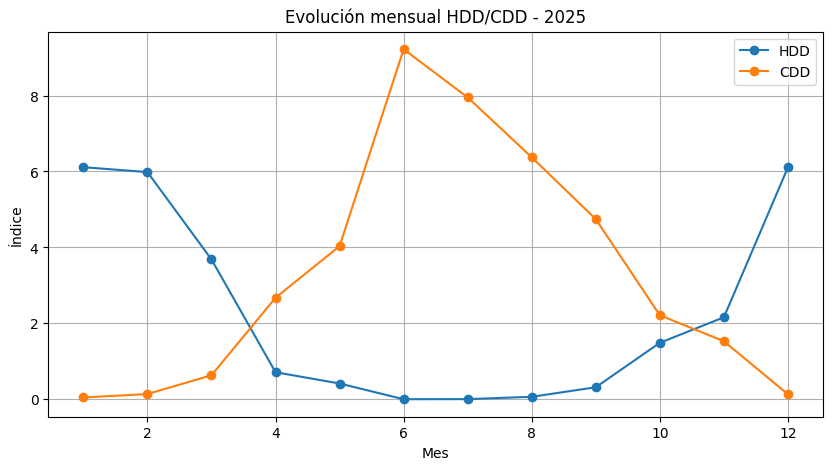

In [86]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(df_chdd_mes["mes"], df_chdd_mes["hdd"], marker="o", label="HDD")
plt.plot(df_chdd_mes["mes"], df_chdd_mes["cdd"], marker="o", label="CDD")

plt.xlabel("Mes")
plt.ylabel("Índice")
plt.title("Evolución mensual HDD/CDD - 2025")
plt.grid()
plt.legend()

plt.show()

# Modelo adaptado a regresión lineal

$$
c(t) = B + \beta_c \cdot HDD(t) + \beta_f \cdot CDD(t)
$$

$$
c(X(t)) = B + m \cdot X(t)  
$$

- $B$: consumo base del cliente  
- $X(t)$: Tanto $HDD(t)$ como $CDD(t)$ varían en función del tiempo de forma aproximadamente cíclica. Sabiendo que tenemos máximos de calor en verano, mínimos en invierno y que las desviaciones de la temperatura en valor absoluto con respecto a la $T_{comfort}$ alcanzan mínimos en otoño y primavera, podemos pensar $X(t)$ como una combinación de senos y cosenos tomando $HDD(t)$ y $CDD(t)$ como amplitudes de sus respectivas funciones de onda, siendo una suposición inicial que $X(t)$ adoptaba la siguiente forma general:
$$
$$
$ X(t) = \left|\overline{HDD}(t)\cdot sin((\frac{\pi}{12})\cdot t)\right| + \left|\overline{CDD}(t)\cdot cos((\frac{\pi}{12})\cdot t)\right|$
---

No obstante, siendo HDD y CDD diferencias de temperatura con respecto a $T_{comfort}$, debido a que HDD disminuye cuando CDD se incrementa, y viceversa, se planteó una igualdad más simple, detallada mediante la expresión visible a continuación:

$$
X(t) = HDD(t) + CDD(t)
$$



In [87]:
df_chdd_mes['CCD + HDD']=df_chdd_mes['cdd']+df_chdd_mes['hdd']
df_chdd_mes


,mes,hdd,cdd,CCD + HDD
0,1,6.112500,0.047043,6.159543
1,2,5.983780,0.137798,6.121577
2,3,3.683468,0.631989,4.315457
3,4,0.712083,2.674167,3.386250
4,5,0.415323,4.033065,4.448387
5,6,0.001250,9.219722,9.220972
6,7,0.004167,7.950134,7.954301
7,8,0.064785,6.373656,6.438441
8,9,0.316528,4.743889,5.060417
9,10,1.487500,2.213038,3.700538


In [98]:
CDD_HDD_L = df_chdd_mes['CCD + HDD'].tolist()

In [104]:
# LIMPIEZA DEL DATASET SIN ELIMINAR FILAS CON VALORES NULOS Y SIN QUITAR LAS BAJAS.
df_completo_limpio = limpiar_dataset(
    df_completo,
    sin_bajas=False,
    sacar_nulos=False, 
    sacar_duplicados=True
).sort_values(by=['ID','REFERENCIA']) 



In [105]:
df_completo_limpio['REFERENCIA'].value_counts().sort_index()

REFERENCIA
1     39300
2     39420
3     39579
4     39750
5     79688
6     79816
7     39947
8     79907
9     79908
10    39855
11    78598
12    76025
Name: count, dtype: int64

In [ ]:
#CORRECCION DEL DATAFRAME:
df_mes = (
    df_completo_limpio.sort_values(['ID','REFERENCIA','FECHA LETT ACT'])
    .groupby(['ID','REFERENCIA'], as_index=False)
    .last() # quedarnos con la última lectura de cada cliente en cada mes, ya que es la que tiene el consumo total final
)

CONS_TOT_FIN_CORR = df_mes.groupby('REFERENCIA')['CONSUMO TOTAL FINAL'].sum()

In [108]:
#CONSUMO TOTAL FINAL POR MES DE REFERENCIA. ESTOS SERÁN LOS VALORES DE LA VARIABLE DEPENDIENTE Y.
df_mes.groupby('REFERENCIA')['CONSUMO TOTAL FINAL'].sum()

REFERENCIA
1     2.505308e+07
2     2.395766e+07
3     2.323285e+07
4     1.943134e+07
5     2.265241e+07
6     2.872607e+07
7     3.065304e+07
8     2.835014e+07
9     2.373660e+07
10    2.179048e+07
11    2.050830e+07
12    2.492334e+07
Name: CONSUMO TOTAL FINAL, dtype: float64

In [112]:
# CONVERTIMOS DICHOS VALORES DE VARIABLE DEPENDIENTE A UNA LISTA.
CONS_TOT_FIN_SUM = df_mes.groupby('REFERENCIA')['CONSUMO TOTAL FINAL'].sum().div(1e6) # dividimos por 1 millón para convertir a millones de kWh (GWh), y así tener una escala más manejable para la regresión lineal.

CONS_TOT_FIN_SUM_L = CONS_TOT_FIN_SUM.tolist()


Ecuación: y = 1.72x + 14.86
R2: 0.84
MSE: 1.69


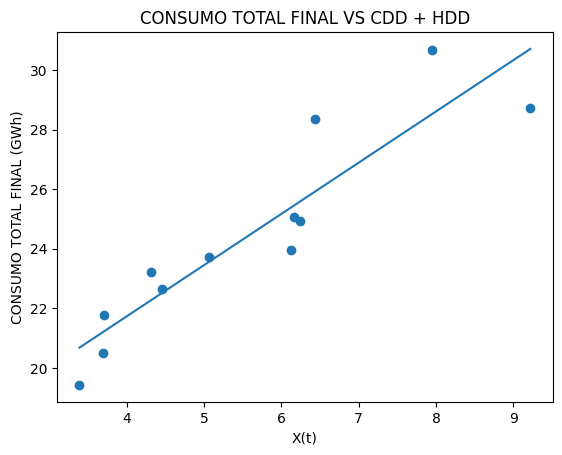

In [114]:
# REGRESIÓN LINEAL:
# CDD + HDD

x = np.array(CDD_HDD_L).reshape(-1,1) # CDD + HDD almacenados en una lista, los cuales son almacenados en otro objeto, un vector, cambiando sus dimensiones para convertir de vector fila a vector columna.
y = np.array(CONS_TOT_FIN_SUM_L) # SUMA DE CONSUMO TOTAL FINAL también almacenado en lista previamente, ahora se guardan en otro vector, pero sin convertir a vector fila.

#x es necesario transponerlo, pero no y.
#En definitiva,

#definimos la variable modelo:
modelo = LinearRegression()
modelo.fit(x, y) # le damos las variables al modelo.

pendiente = modelo.coef_[0] # variable pendiente
interseccion = modelo.intercept_ #variable ordenada al origen

y_pred = modelo.predict(x) #array de elementos y predichos por el modelo para cada valor de x provisto al mismo (véase variables anteriores).

r2 = r2_score(y, y_pred) # --> más alto, mayor variablilidad explicada por la variable dependiente.
mse = mean_squared_error(y, y_pred) #error cuadrático medio.


#Resultados:
print(f"Ecuación: y = {pendiente:.2f}x + {interseccion:.2f}")
print (f"R2: {r2:.2f}")
print (f"MSE: {mse:.2f}")
plt.scatter(x, y)

x_line = np.linspace(x.min(), x.max(), 100).reshape(-1,1)
y_line = modelo.predict(x_line)

plt.plot(x_line, y_line)
plt.title('CONSUMO TOTAL FINAL VS CDD + HDD')
plt.xlabel('X(t)')
plt.ylabel('CONSUMO TOTAL FINAL (GWh)')
plt.show()


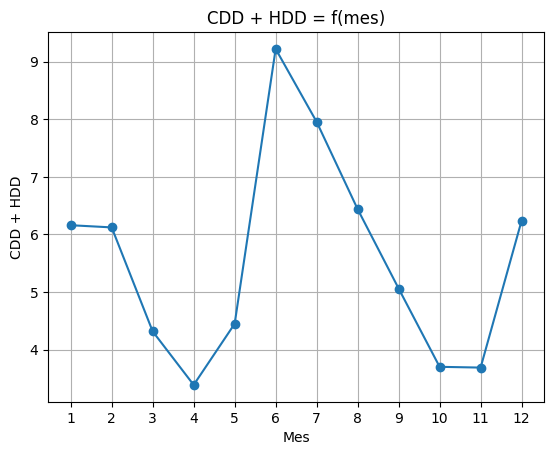

In [117]:
#Gráfico de (CDD + HDD) vs mes

plt.plot(df_chdd_mes['mes'], df_chdd_mes['CCD + HDD'], marker='o')
plt.title('CDD + HDD = f(mes)')
plt.xlabel('Mes')
plt.ylabel('CDD + HDD')
plt.grid()
plt.xticks(df_chdd_mes['mes'])
plt.show()

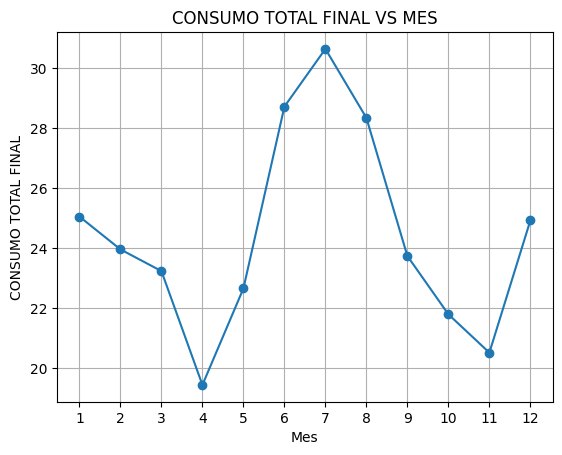

In [119]:
# GRÁFICO DE CONSUMO TOTAL FINAL EN CADA MES:
CONS_TOT_FIN_SUM_2 = CONS_TOT_FIN_SUM.reset_index()
plt.plot(CONS_TOT_FIN_SUM_2['REFERENCIA'],CONS_TOT_FIN_SUM_2['CONSUMO TOTAL FINAL'], marker='o')
plt.title('CONSUMO TOTAL FINAL VS MES')
plt.xlabel('Mes')
plt.ylabel('CONSUMO TOTAL FINAL')
plt.grid()
plt.xticks(CONS_TOT_FIN_SUM_2['REFERENCIA'])
plt.show()

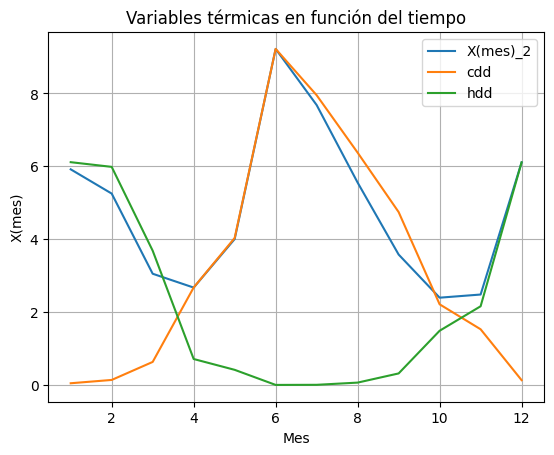

In [122]:
df_chdd_mes['X(t)_1'] = df_chdd_mes['CCD + HDD']*np.sin(12/(2*np.pi)*(df_chdd_mes['mes']+1))
df_chdd_mes['X(t)_2'] = np.abs(df_chdd_mes['hdd']*np.cos((((np.pi)/12)*(df_chdd_mes['mes'])))) + np.abs(df_chdd_mes['cdd']*np.sin((((np.pi)/12)*(df_chdd_mes['mes']))))


plt.plot(df_chdd_mes['mes'],df_chdd_mes['X(t)_2'])

plt.plot(df_chdd_mes['mes'],df_chdd_mes['cdd'])
plt.plot(df_chdd_mes['mes'],df_chdd_mes['hdd'])
plt.title('Variables térmicas en función del tiempo')
plt.xlabel('Mes')
plt.ylabel('X(mes)')
plt.grid()
plt.legend(['X(mes)_2','cdd','hdd'])
plt.show()


In [38]:
df_chdd_mes

,mes,hdd,cdd,CCD + HDD,X(t)_1,X(t)_2
0,1,6.112500,0.047043,6.159543,-3.864095,5.916397
1,2,5.983780,0.137798,6.121577,-3.218476,5.251004
2,3,3.683468,0.631989,4.315457,4.216519,3.051489
3,4,0.712083,2.674167,3.386250,-0.420562,2.671938
4,5,0.415323,4.033065,4.448387,-3.978890,4.003135
5,6,0.001250,9.219722,9.220972,6.631687,9.219722
6,7,0.004167,7.950134,7.954301,3.309326,7.680319
7,8,0.064785,6.373656,6.438441,-6.412368,5.552140
8,9,0.316528,4.743889,5.060417,1.247246,3.578255
9,10,1.487500,2.213038,3.700538,3.078833,2.394732


In [39]:
df_chdd_mes.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   mes        12 non-null     int32  
 1   hdd        12 non-null     float64
 2   cdd        12 non-null     float64
 3   CCD + HDD  12 non-null     float64
 4   X(t)_1     12 non-null     float64
 5   X(t)_2     12 non-null     float64
dtypes: float64(5), int32(1)
memory usage: 660.0 bytes


# *BONUS: PRUEBA DEL MODELO SINUSOIDAL*


Ecuación: y = 1.36x + 17.84
R2: 0.77
MSE: 2.37


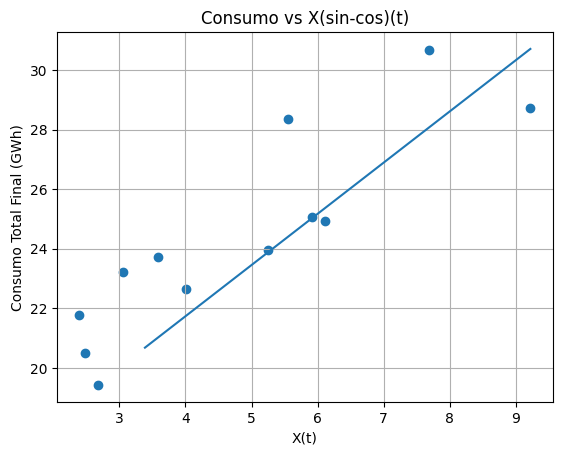

In [125]:
X2_L = df_chdd_mes['X(t)_2'].tolist()

df_modelo_ondas = pd.DataFrame({'X':X2_L, 'Y':CONS_TOT_FIN_SUM_L})


X_sin = np.array(df_modelo_ondas['X'].to_list()).reshape(-1,1)
y_sin = np.array(df_modelo_ondas['Y'].to_list())
y_2 = np.array(CONS_TOT_FIN_SUM_L)

modelo_sin = LinearRegression()
modelo_sin.fit(X_sin, y_sin)

pendiente_sin = modelo_sin.coef_[0]
interseccion_sin = modelo_sin.intercept_

y_pred_sin = modelo_sin.predict(X_sin)

r2_sin = r2_score(y_2, y_pred_sin)
mse_sin = mean_squared_error(y_2, y_pred_sin)

print(f"Ecuación: y = {pendiente_sin:.2f}x + {interseccion_sin:.2f}")
print (f"R2: {r2_sin:.2f}")
print (f"MSE: {mse_sin:.2f}")

plt.scatter(X_sin, y_sin)

x_line = np.linspace(x.min(), x.max(), 100).reshape(-1,1)
y_line = modelo.predict(x_line)
plt.title('Consumo vs X(sin-cos)(t)')
plt.xlabel('X(t)')
plt.ylabel('Consumo Total Final (GWh)')
plt.plot(x_line, y_line)
plt.grid()
plt.show()

In [41]:
'''
#DATAFRAME - 2026



# df_CONS_26 = pd.DataFrame( TABLA DE CONSUMOS 2026)
# df_T_26 = pd.DataFrame( TABLA DE TEMPERATURAS 2026)

#------------|------------#
#------------|------------#
#               DIAS EST



def Cons_Est(beta_c, beta_h, b):
  # Lim_inf = [FECHA LETT ACT]
  # Lim_sup = [FECHA LETT ACT] + df_CONS_26['DIAS ESTIMAR']
  #
  # INT_DIAS_INTERMEDIOS = [for Lim_inf]
  Cons_Est_var = np.array(for b + beta_c *
# df_CONS_26[CONS_EST] = f(CDD,HDD)
'''

"\n#DATAFRAME - 2026\n\n\n\n# df_CONS_26 = pd.DataFrame( TABLA DE CONSUMOS 2026)\n# df_T_26 = pd.DataFrame( TABLA DE TEMPERATURAS 2026)\n\n#------------|------------#\n#------------|------------#\n#               DIAS EST\n\n\n\ndef Cons_Est(beta_c, beta_h, b):\n  # Lim_inf = [FECHA LETT ACT]\n  # Lim_sup = [FECHA LETT ACT] + df_CONS_26['DIAS ESTIMAR']\n  #\n  # INT_DIAS_INTERMEDIOS = [for Lim_inf]\n  Cons_Est_var = np.array(for b + beta_c *\n# df_CONS_26[CONS_EST] = f(CDD,HDD)\n"

# Modelos propuestos para la estimación del consumo energético

Con el objetivo de analizar la relación entre el consumo energético y las condiciones térmicas ambientales, se evaluarán tres formulaciones alternativas basadas en las variables Heating Degree Days (HDD) y Cooling Degree Days (CDD).

La motivación de este análisis surge de que ambas variables representan desviaciones de la temperatura respecto de una temperatura de confort ($T_{comfort}$), aunque en regímenes opuestos: HDD cuantifica la necesidad de calefacción en condiciones frías, mientras que CDD cuantifica la necesidad de refrigeración en condiciones cálidas.

Se estudiarán los siguientes modelos:

## Modelo 1: Regresión lineal compuesta

Se considera que el consumo responde de forma diferente a las necesidades de calefacción y refrigeración, permitiendo estimar sensibilidades independientes para cada fenómeno.

$$
c(t)=B+\beta_c\cdot HDD(t)+\beta_f\cdot CDD(t)
$$

donde:

* $c(t)$: consumo observado.
* $B$: consumo base del cliente.
* $\beta_c$: sensibilidad del consumo frente al frío.
* $\beta_f$: sensibilidad del consumo frente al calor.

Este modelo constituye la formulación más general y será utilizado como referencia para evaluar la capacidad explicativa de las simplificaciones posteriores.

---

## Modelo 2: Variable térmica agregada

Dado que HDD y CDD representan desviaciones respecto de la misma temperatura de confort y presentan un comportamiento complementario a lo largo del año, se propone construir una única variable térmica:

$$
X(t)=HDD(t)+CDD(t)
$$

De esta manera, el modelo se simplifica a:

$$
c(X(t))=B+m\cdot X(t)
$$

donde $m$ representa la sensibilidad global del consumo frente a la desviación térmica total.

Esta formulación permite evaluar si la información contenida en HDD y CDD puede resumirse adecuadamente mediante una única variable explicativa.

---

## Modelo 3: Variable térmica estacional

Considerando que HDD y CDD presentan un comportamiento aproximadamente periódico a lo largo del año, se propone una variable térmica que incorpore explícitamente la componente estacional mediante funciones trigonométricas:

$$
X(t)=
\left|
HDD(t)\cdot \cos\left(\frac{\pi}{12}t\right)
\right|
+
\left|
CDD(t)\cdot \sin\left(\frac{\pi}{12}t\right)
\right|
$$


La variable obtenida se utilizará dentro del modelo:

$$
c(X(t))=B+m\cdot X(t)
$$

El objetivo es analizar si la incorporación explícita de la periodicidad anual permite representar de manera más adecuada la influencia de las condiciones térmicas sobre el consumo.

---

Finalmente, se compararán los tres modelos utilizando métricas de ajuste y capacidad explicativa, con el fin de determinar cuál representa mejor el comportamiento observado del consumo energético.

## **Modelo 1: Regresión lineal Multiple**
Como primera aproximación se considera que el consumo energético puede responder de manera diferente a las necesidades de calefacción y refrigeración. Para ello se plantea el siguiente modelo de regresión lineal múltiple:

$
c(t)=B+\beta_c\cdot HDD(t)+\beta_f\cdot CDD(t)
$

#### **Metodología**

La estimación de los parámetros se realizará mediante mínimos cuadrados ordinarios (OLS), minimizando la suma de los errores cuadráticos entre los valores observados y los valores predichos por el modelo.

Una vez ajustado el modelo se analizarán:

Los coeficientes estimados.
El coeficiente de determinación $(R^2)$.
Los residuos del ajuste.
La capacidad predictiva del modelo.

#### **Resultados esperados**

Si el comportamiento del consumo depende efectivamente tanto de HDD como de CDD, se espera obtener un buen ajuste y coeficientes estadísticamente significativos para ambas variables.

Este modelo servirá además como referencia para comparar posteriormente las simplificaciones propuestas en los Modelos 2 y 3.

In [131]:
df_consumo = (df_mes.groupby('REFERENCIA')['CONSUMO TOTAL FINAL'].sum().div(1e6)).reset_index() # dividimos por 1 millón para convertir a millones de kWh (GWh), y así tener una escala más manejable para la regresión lineal.
df_chdd_mes_renamed = df_chdd_mes.rename(columns={'mes': 'REFERENCIA'})

df_modelo_1 = (df_consumo.merge(df_chdd_mes_renamed[['REFERENCIA','hdd','cdd']], on='REFERENCIA',how='inner'))
df_modelo_1

,REFERENCIA,CONSUMO TOTAL FINAL,hdd,cdd
0,1,25.053081,6.112500,0.047043
1,2,23.957665,5.983780,0.137798
2,3,23.232849,3.683468,0.631989
3,4,19.431345,0.712083,2.674167
4,5,22.652412,0.415323,4.033065
5,6,28.726069,0.001250,9.219722
6,7,30.653044,0.004167,7.950134
7,8,28.350141,0.064785,6.373656
8,9,23.736598,0.316528,4.743889
9,10,21.790480,1.487500,2.213038


In [132]:
X = df_modelo_1[['hdd','cdd']]
y = df_modelo_1['CONSUMO TOTAL FINAL']

modelo_1 = LinearRegression()
modelo_1.fit(X,y)

B = modelo_1.intercept_
beta_c = modelo_1.coef_[0]
beta_f = modelo_1.coef_[1]

y_pred = modelo_1.predict(X)

r2 = r2_score(y,y_pred)

print(f'B      = {B:.4f}')
print(f'βc     = {beta_c:.4f}')
print(f'βf     = {beta_f:.4f}')
print(f'R²     = {r2:.4f}')

B      = 15.3351
βc     = 1.5264
βf     = 1.7062
R²     = 0.8572


In [197]:
import statsmodels.api as sm

X = df_modelo_1[['hdd','cdd']]# Variables explicativas

X = sm.add_constant(X)# Agregar constante (intercepto)

y = df_modelo_1['CONSUMO TOTAL FINAL']# Variable respuesta

modelo_sm = sm.OLS(y, X).fit()# Ajuste del modelo

print(modelo_sm.summary())

                             OLS Regression Results                            
Dep. Variable:     CONSUMO TOTAL FINAL   R-squared:                       0.857
Model:                             OLS   Adj. R-squared:                  0.825
Method:                  Least Squares   F-statistic:                     27.00
Date:                 Sun, 07 Jun 2026   Prob (F-statistic):           0.000157
Time:                         20:34:51   Log-Likelihood:                -19.451
No. Observations:                   12   AIC:                             44.90
Df Residuals:                        9   BIC:                             46.36
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         15.3351      1.445     10.61

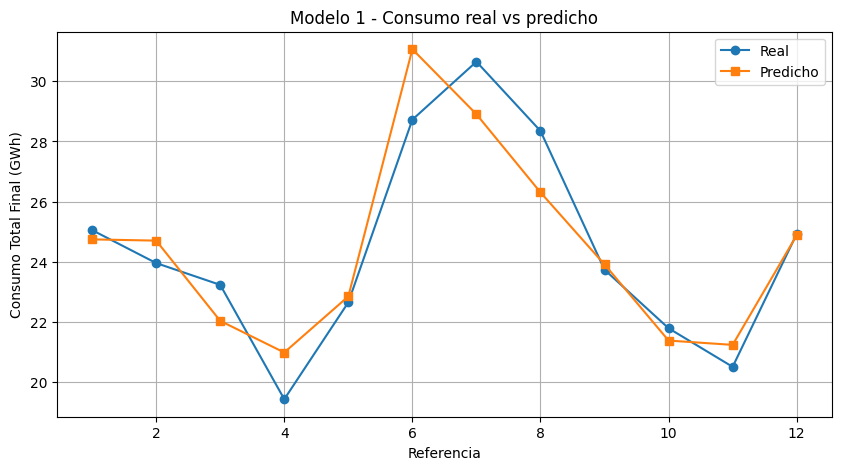

In [134]:
plt.figure(figsize=(10,5))
plt.plot(df_modelo_1['REFERENCIA'], y,marker='o', label='Real')
plt.plot(df_modelo_1['REFERENCIA'], y_pred, marker='s', label='Predicho')

plt.xlabel('Referencia')
plt.ylabel('Consumo Total Final (GWh)')
plt.title('Modelo 1 - Consumo real vs predicho')

plt.grid(True)
plt.legend()

plt.show()

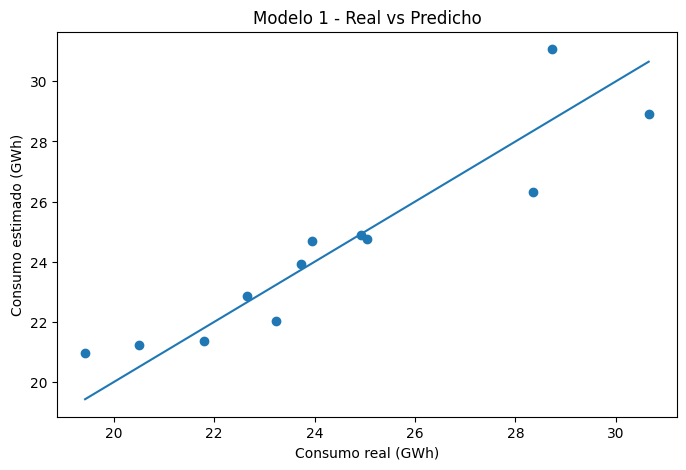

In [136]:
plt.figure(figsize=(8,5))

plt.scatter(y, y_pred)

plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()]
)

plt.xlabel('Consumo real (GWh)')
plt.ylabel('Consumo estimado (GWh)')
plt.title('Modelo 1 - Real vs Predicho')

plt.show()

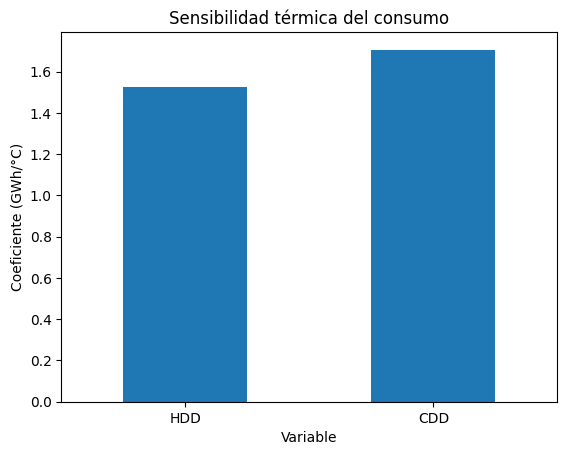

In [198]:
coeficientes = pd.DataFrame({'Variable':['HDD','CDD'],'Coeficiente':[beta_c,beta_f]})

coeficientes.plot(x='Variable',y='Coeficiente',kind='bar',legend=False)

plt.ylabel('Coeficiente (GWh/°C)')
plt.title('Sensibilidad térmica del consumo')
plt.xticks(rotation=0)
plt.show()

# **Modelo 2: Variable térmica agregada**

## Formulación del modelo

A partir de los resultados obtenidos en el Modelo 1, se propone una simplificación basada en la hipótesis de que las variables HDD y CDD representan una misma magnitud física: la desviación de la temperatura respecto de una temperatura de confort.

Dado que HDD aumenta cuando la temperatura se encuentra por debajo de la temperatura de confort y CDD aumenta cuando la temperatura se encuentra por encima de ella, ambas variables describen distintos comportamientos de un mismo fenómeno térmico.

Bajo esta hipótesis, se define la siguiente variable agregada:

$$
X(t)=HDD(t)+CDD(t)
$$

La variable (X(t)) representa la magnitud total de desviación térmica respecto de la temperatura de confort, independientemente de si dicha desviación corresponde a condiciones de frío o de calor.

Utilizando esta nueva variable, el modelo de regresión queda definido como:

$$
c(X(t))=B+m\cdot X(t)
$$

donde:

* $(c(X(t)))$: consumo energético observado.
* $(B)$: consumo base del cliente.
* $(X(t))$: variable térmica agregada.
* $(m)$: sensibilidad global del consumo frente a las desviaciones térmicas.

---

## Objetivo

El objetivo de este modelo es evaluar si la información contenida en las variables HDD y CDD puede resumirse adecuadamente mediante una única variable explicativa sin perder capacidad predictiva.

Esta simplificación permite reducir la complejidad del modelo, pasando de dos parámetros térmicos independientes $(\beta_c)$ y $(\beta_f)$ a un único parámetro de sensibilidad global $(m)$.

---

## Hipótesis de trabajo

La hipótesis subyacente es que el consumo energético depende principalmente de la magnitud de la desviación respecto de la temperatura de confort y no necesariamente del sentido de dicha desviación.

Bajo esta suposición, períodos con necesidades de calefacción y períodos con necesidades de refrigeración generarían incrementos de consumo de naturaleza comparable, permitiendo describir ambos comportamientos mediante una única variable térmica.

---

## Metodología

La variable $(X(t))$ se calcula para cada período como la suma de los valores de HDD y CDD:
$$
X(t)=HDD(t)+CDD(t)
$$

Posteriormente se ajusta una regresión lineal simple mediante mínimos cuadrados ordinarios para estimar los parámetros $(B)$ y $(m)$.

Una vez ajustado el modelo se analizarán:

* El valor estimado de $(B)$.
* El valor estimado de $(m)$.
* El coeficiente de determinación $(R^2)$.
* Los residuos del ajuste.
* La comparación de desempeño respecto del Modelo 1.

---

## Criterio de comparación

El desempeño de este modelo será comparado con el obtenido en el Modelo 1.

Si el coeficiente de determinación $(R^2)$ permanece cercano al obtenido mediante la regresión compuesta, podrá concluirse que la variable agregada conserva la mayor parte de la información explicativa presente en HDD y CDD.

Por el contrario, una disminución significativa en la capacidad predictiva indicaría que las contribuciones del frío y del calor presentan comportamientos diferenciados y requieren ser modeladas mediante coeficientes independientes.


In [140]:
df_modelo_2 = df_modelo_1[["REFERENCIA", "CONSUMO TOTAL FINAL"]].copy()

df_modelo_2['X'] = df_chdd_mes['CCD + HDD']

df_modelo_2

,REFERENCIA,CONSUMO TOTAL FINAL,X
0,1,25.053081,6.159543
1,2,23.957665,6.121577
2,3,23.232849,4.315457
3,4,19.431345,3.386250
4,5,22.652412,4.448387
5,6,28.726069,9.220972
6,7,30.653044,7.954301
7,8,28.350141,6.438441
8,9,23.736598,5.060417
9,10,21.790480,3.700538


In [141]:
X = df_modelo_2[['X']]
y = df_modelo_2['CONSUMO TOTAL FINAL']

modelo_2 = LinearRegression()
modelo_2.fit(X,y)

B_2 = modelo_2.intercept_
m = modelo_2.coef_[0]

y_pred_2 = modelo_2.predict(X)

r2_2 = r2_score(y,y_pred_2)

print(f'B  = {B_2:.4f}')
print(f'm  = {m:.4f}')
print(f'R² = {r2_2:.4f}')

B  = 14.8645
m  = 1.7179
R² = 0.8390


In [142]:
X_sm = sm.add_constant(df_modelo_2[['X']])

modelo_2_sm = sm.OLS(y, X_sm).fit()

print(modelo_2_sm.summary())

                             OLS Regression Results                            
Dep. Variable:     CONSUMO TOTAL FINAL   R-squared:                       0.839
Model:                             OLS   Adj. R-squared:                  0.823
Method:                  Least Squares   F-statistic:                     52.12
Date:                 Sun, 07 Jun 2026   Prob (F-statistic):           2.86e-05
Time:                         17:03:58   Log-Likelihood:                -20.167
No. Observations:                   12   AIC:                             44.33
Df Residuals:                       10   BIC:                             45.30
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         14.8645      1.386     10.72

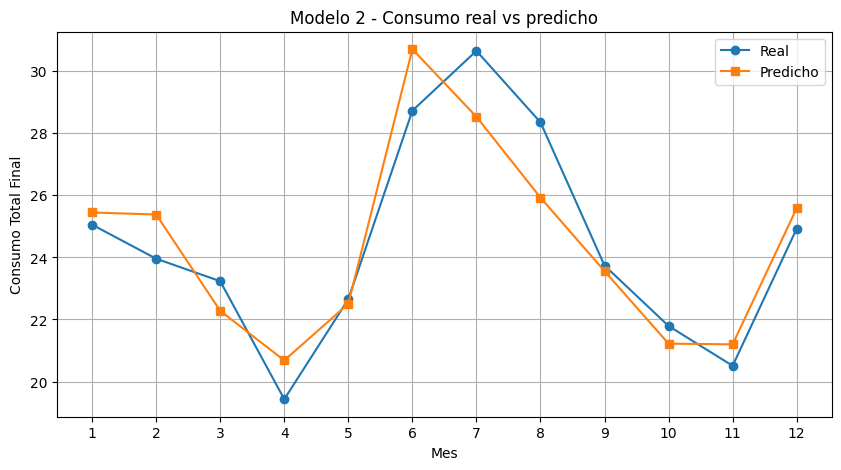

In [143]:
plt.figure(figsize=(10,5))

plt.plot(df_modelo_2['REFERENCIA'], y, marker='o',label='Real')

plt.plot(df_modelo_2['REFERENCIA'], y_pred_2, marker='s',label='Predicho')

plt.xticks(range(1,13))
plt.xlabel('Mes')
plt.ylabel('Consumo Total Final')
plt.title('Modelo 2 - Consumo real vs predicho')

plt.grid(True)
plt.legend()

plt.show()

# Modelo 3: Variable térmica estacional

## Formulación del modelo

Los modelos anteriores utilizan únicamente la magnitud de las variables térmicas HDD y CDD para explicar el consumo energético.

Sin embargo, tanto las necesidades de calefacción como las de refrigeración presentan un comportamiento aproximadamente periódico a lo largo del año debido a la naturaleza estacional de las temperaturas.

Con el objetivo de incorporar explícitamente esta componente temporal, se propone la construcción de una variable térmica estacional definida como:

$
X(t)=
\left|
HDD(t)\cdot \cos\left(\frac{\pi}{12}t\right)
\right|
+
\left|
CDD(t)\cdot \sin\left(\frac{\pi}{12}t\right)
\right|
$

donde:

* $(t)$ representa el mes del año.
* $(HDD(t)$) corresponde a los Heating Degree Days del período.
* $(CDD(t))$ corresponde a los Cooling Degree Days del período.

Las funciones trigonométricas permiten representar la periodicidad anual de las condiciones climáticas, ponderando la contribución de HDD y CDD según la época del año.

---

## Objetivo

El objetivo de este modelo es analizar si la incorporación explícita de la estacionalidad mejora la representación de la relación entre las variables térmicas y el consumo energético.

A diferencia del Modelo 2, que considera únicamente la magnitud total de la desviación térmica, este enfoque intenta incorporar información adicional relacionada con la evolución temporal de las condiciones climáticas.

---

## Modelo de regresión

La variable térmica estacional se utiliza como única variable explicativa dentro de una regresión lineal simple:

$$
c(X(t))=B+m\cdot X(t)
$$

donde:

* $(c(X(t)))$: consumo energético observado.
* $(B)$: consumo base del cliente.
* $(m)$: sensibilidad del consumo frente a la variable térmica estacional.
* $(X(t))$: variable térmica corregida mediante funciones trigonométricas.

---

## Metodología

Para cada mes se calcula el valor de $(X(t))$ utilizando los valores observados de HDD y CDD.

Posteriormente se ajusta una regresión lineal simple mediante mínimos cuadrados ordinarios para estimar los parámetros $(B)$ y $(m)$.



In [144]:
df_modelo_3 = df_modelo_2[["REFERENCIA", "CONSUMO TOTAL FINAL"]].copy()

df_modelo_3['X_estacional'] = df_chdd_mes['X(t)_2']
df_modelo_3

,REFERENCIA,CONSUMO TOTAL FINAL,X_estacional
0,1,25.053081,5.916397
1,2,23.957665,5.251004
2,3,23.232849,3.051489
3,4,19.431345,2.671938
4,5,22.652412,4.003135
5,6,28.726069,9.219722
6,7,30.653044,7.680319
7,8,28.350141,5.552140
8,9,23.736598,3.578255
9,10,21.790480,2.394732


In [145]:
X = df_modelo_3[['X_estacional']]
y = df_modelo_3['CONSUMO TOTAL FINAL']

modelo_3 = LinearRegression()
modelo_3.fit(X,y)

B_3 = modelo_3.intercept_
m_3 = modelo_3.coef_[0]

y_pred_3 = modelo_3.predict(X)

r2_3 = r2_score(y,y_pred_3)

print(f'B  = {B_3:.4f}')
print(f'm  = {m_3:.4f}')
print(f'R² = {r2_3:.4f}')

B  = 17.8428
m  = 1.3626
R² = 0.7736


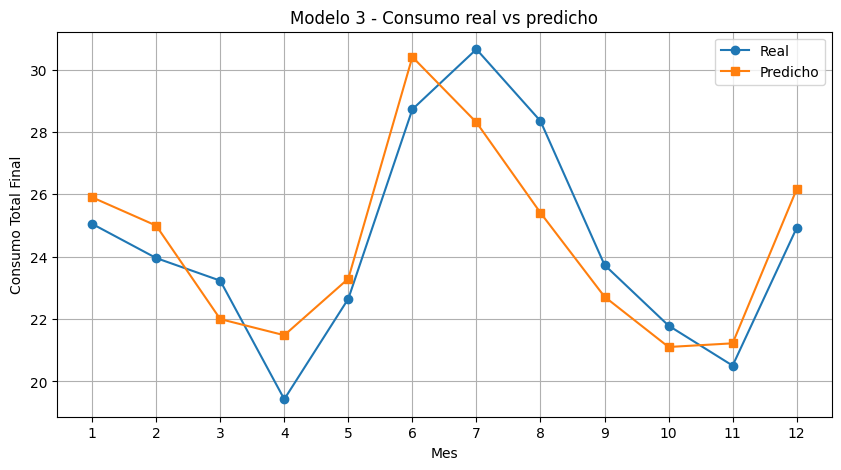

In [146]:
plt.figure(figsize=(10,5))

plt.plot(df_modelo_3['REFERENCIA'],y,marker='o',label='Real')

plt.plot(df_modelo_3['REFERENCIA'],y_pred_3,marker='s',label='Predicho')

plt.xticks(range(1,13))
plt.xlabel('Mes')
plt.ylabel('Consumo Total Final')
plt.title('Modelo 3 - Consumo real vs predicho')

plt.grid(True)
plt.legend()

plt.show()

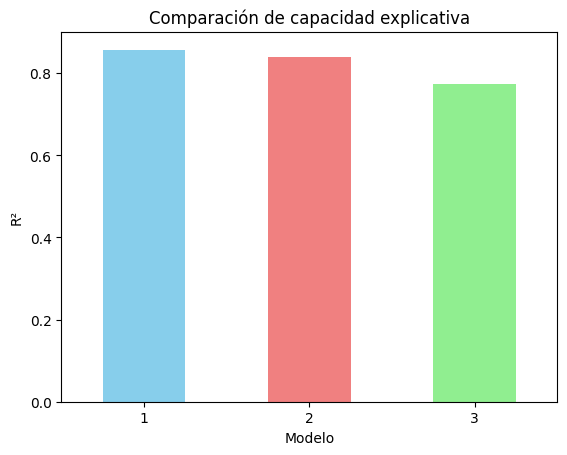

In [149]:
comparacion = pd.DataFrame({'Modelo':['1','2','3'],'R2':[0.8572,0.8390,0.7736]})

# Define a list of colors for each model
colors = ['skyblue', 'lightcoral', 'lightgreen']

comparacion.plot(x='Modelo',y='R2',kind='bar',legend=False, color=colors)

plt.ylabel('R²')
plt.title('Comparación de capacidad explicativa')
plt.xticks(rotation=0)
plt.show()

In [150]:
print("Comparación de Modelos\n")

print(f"Modelo 1 - Regresión múltiple (HDD + CDD por separado): R² = {r2:.4f}")
print(f"Modelo 2 - Variable agregada X = HDD + CDD:             R² = {r2_2:.4f}")
print(f"Modelo 3 - Variable estacional X(t):                    R² = {r2_3:.4f}")

print("\nDiferencias respecto al Modelo 1")
print(f"M1 - M2 = {(r2-r2_2):.4f}")
print(f"M1 - M3 = {(r2-r2_3):.4f}")

Comparación de Modelos

Modelo 1 - Regresión múltiple (HDD + CDD por separado): R² = 0.8572
Modelo 2 - Variable agregada X = HDD + CDD:             R² = 0.8390
Modelo 3 - Variable estacional X(t):                    R² = 0.7736

Diferencias respecto al Modelo 1
M1 - M2 = 0.0181
M1 - M3 = 0.0836


# Criterio

Se evaluaron tres modelos de regresión con el objetivo de analizar la relación entre el consumo energético y las variables térmicas HDD y CDD.

El Modelo 1, basado en una regresión lineal múltiple con HDD y CDD como variables independientes, obtuvo el mejor desempeño, alcanzando un coeficiente de determinación de $(R^2 = 0.8572)$. Esto indica que aproximadamente el 85,72% de la variabilidad observada en el consumo es explicada por las variables térmicas consideradas.

Posteriormente se analizó una simplificación del modelo mediante la construcción de una variable agregada definida como:

$$
X(t)=HDD(t)+CDD(t)
$$

El Modelo 2 obtuvo un coeficiente de determinación de $(R^2 = 0.8390)$, mostrando una reducción de apenas **0,0181** respecto al Modelo 1. Esta diferencia representa una pérdida relativamente pequeña de capacidad explicativa, sugiriendo que la variable agregada conserva gran parte de la información contenida en HDD y CDD por separado.

Finalmente, se evaluó un Modelo 3 que incorpora explícitamente una componente estacional mediante funciones trigonométricas. En este caso se obtuvo un coeficiente de determinación de $(R^2 = 0.7736)$, inferior al de los dos modelos anteriores. Para este conjunto de datos, la incorporación de dicha transformación no produjo una mejora en la capacidad predictiva del modelo.

A partir de los resultados obtenidos, puede concluirse que el Modelo 1 proporciona el mejor ajuste estadístico. Sin embargo, el Modelo 2 presenta un desempeño muy cercano, manteniendo una estructura significativamente más simple al reemplazar dos variables explicativas por una única variable térmica agregada.

En consecuencia, la hipótesis planteada inicialmente resulta compatible con los resultados observados: dado que HDD y CDD representan desviaciones de la temperatura respecto de una temperatura de confort, la variable agregada $(X(t)=HDD(t)+CDD(t))$ logra capturar gran parte de la información relevante para explicar el consumo energético, con una pérdida limitada de capacidad explicativa respecto al modelo completo.


# **Consumo real 2026 - Consumo Estimado Modelo Empresa**

La estimación de consumo de 2026, aplicando el Modelo 1, arroja los resultados que se muestran en la sección anterior, pero la comparación con el consumo real es aquello que permitirá determinar si el modelo aplicado describe de forma más fiel a la realidad el comportamiento de los clientes mes a mes que el modelo aplicado actualmente en la empresa.

A continuación se obtendrá el comportamiento real, la comparativa vs modelo actualmente utilizado en la empresa y modelo propuesto (Modelo 1) y conclusiones finales.

Hemos visto anteriormente que el modelo que utiliza la empresa para estimar el consumo de cada cliente en los intervalos de tiempo comprendidos entre la última fecha de lectura de ese cliente hasta el último día del mes (Días Estimar) responde a la siguiente igualdad:

$$
Consumo Estimado = [Factor Estacional] \cdot [Promedio Consumo] \cdot [Días Estimar]
$$

$$
Factor Estacional = \frac{\frac{\text {Demanda periodo dias estimar}}{\text{dias estimar}}}{\frac{\text{Demanda periodo dias leidos}}{\text{Dias Leidos}}}
$$

Sería una comparación dispar intentar evaluar el modelo propuesto (Modelo 1) que se utiliza para estimar meses completos, contrastándolo contra el modelo de Factor Estacional que utiliza la empresa actualmente, el cuál sólo estima días del mes sin lectura.

Para poder evaluar ambos modelos en igualdad de condiciones, se recalculará el consumo estimado para cada cliente, recalculando la demanda en periodo días estimar, tomando los dias a estimar de cada mes para cada cliente como el total de los días del mes de referencia.

Para los días leídos, se tomará el último período leído de cada cliente en 2025 $$([\text{FECHA LETT ACT}] - [\text{FECHA LETT ANT}])_{\text{mes referencia}} $$, en base al cual se obtendrá el promedio de consumo correspondiente. Teniendo dicho período, tomaremos la demanda periodo días leídos que corresponda a dicho período.

Esto lo realizamos utilizando el DataFrame de consumo de 2025 y un dataset de Demanda comprendido entre agosto 2025 hasta mayo 2026 inclusive.




**Demanda**

In [151]:
#Lectura del archivo de Demanda Diaria
url = "https://raw.githubusercontent.com/SantiagoEzequielDrelewicz/TP-LMC/main/Demanda_Consolidado.xlsx"

df_demanda = pd.read_excel(url)
df_demanda

,FECHA,ENERGIA NETO (MWh),ENERGIA NETO kWh
0,2026-04-01,67139.782195,6.713978e+07
1,2026-04-02,56977.728566,5.697773e+07
2,2026-04-03,57106.885810,5.710689e+07
3,2026-04-04,44884.006480,4.488401e+07
4,2026-04-05,41945.840976,4.194584e+07
...,...,...,...
268,2025-08-27,55723.622899,5.572362e+07
269,2025-08-28,54771.665764,5.477167e+07
270,2025-08-29,52800.697402,5.280070e+07
271,2025-08-30,47123.614795,4.712361e+07


**DataFrame de Consumos en 2026 - Obtención de Consumo Total Final**

In [166]:
# Lectura de dataframe con consumos de 2026:

url_cons_2026 = "https://raw.githubusercontent.com/SantiagoEzequielDrelewicz/TP-LMC/main/datos/crudos/CONS_1_2026.parquet"
df_cons_2026 = pd.read_parquet(url_cons_2026)
for col in df_cons_2026.columns: #Columnas con valores "None"
    n = (df_cons_2026[col].astype(str) == "None").sum()

    if n > 0:
        print(col, n)

In [167]:
df_cons_2026.info()

<class 'pandas.DataFrame'>
RangeIndex: 149538 entries, 0 to 149537
Data columns (total 38 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ID                              149538 non-null  float64
 1   PLAN                            149538 non-null  int64  
 2   GRUPPO                          149538 non-null  str    
 3   TARIFA                          149538 non-null  str    
 4   TARIFA DETALLE                  149538 non-null  str    
 5   SUCURSAL                        149538 non-null  str    
 6   TENSION                         149538 non-null  str    
 7   POTENCIA CONTRATADA (KW)        149538 non-null  int64  
 8   FECHA ACTIVACION                149538 non-null  object 
 9   TOTAL ACTIVA                    149538 non-null  int64  
 10  FECHA LETT ANT                  149538 non-null  object 
 11  FECHA LETT ACT                  149538 non-null  object 
 12  FECHA BAJA                 

In [169]:
df_cons_2026[
    ["PROMEDIO CONSUMO", "FACTOR ESTACIONAL", "CONSUMO TOTAL FINAL"]
].dtypes # Los tipos correspondientes a los valores almacenados las columnas PROMEDIO CONSUMO, FACTOR ESTACIONAL y CONSUMO TOTAL FINAL del DataFrame 2026.

PROMEDIO CONSUMO       str
FACTOR ESTACIONAL      str
CONSUMO TOTAL FINAL    str
dtype: object

In [170]:
# Limpieza del dataset 2026 de consumo

RUTA_GUARDADO_3 = "datos/procesados/datos_limpios_2026.csv.gz"

def limpiar_dataset_2026(
    df: pd.DataFrame,
) -> pd.DataFrame:
    """Realiza la limpieza del dataset completo."""

    df_limpio = df.copy()

    # Reemplazar strings "None" por NaN
    df_limpio = df_limpio.replace("None", np.nan)

    # Convertir columnas numéricas con coma decimal
    columnas_con_coma_num = [
        "PROMEDIO CONSUMO",
        "FACTOR ESTACIONAL",
        "CONSUMO TOTAL FINAL"
    ]

    for col in columnas_con_coma_num:

        if col not in df_limpio.columns:
            continue

        df_limpio[col] = pd.to_numeric(
            df_limpio[col]
            .astype(str)
            .str.replace(",", ".", regex=False),
            errors="coerce"
        )

    # En FACTOR ESTACIONAL tiene sentido reemplazar faltantes por 0
    if "FACTOR ESTACIONAL" in df_limpio.columns:
        df_limpio["FACTOR ESTACIONAL"] = (
            df_limpio["FACTOR ESTACIONAL"]
            .fillna(0)
        )

    # Extraer el mes desde AAAAMM
    if "REFERENCIA" in df_limpio.columns:
        df_limpio["REFERENCIA"] = (
            df_limpio["REFERENCIA"]
            .astype(str)
            .str[4:6]
            .astype(int)
        )

    return df_limpio

In [171]:
df_2026 = limpiar_dataset_2026(df_cons_2026)
df_2026

,ID,PLAN,GRUPPO,TARIFA,TARIFA DETALLE,SUCURSAL,TENSION,POTENCIA CONTRATADA (KW),FECHA ACTIVACION,TOTAL ACTIVA,...,AJUSTE,ENERGIA ENTREGADA,OBSERVACION,CLASE DE SERVICIO,CENTRO OPERATIVO,CLIENTE ACTIVO,AJUSTE HASTA,TIPO_LETTURA,CLAVE_LECTURA,column38
0,30829.0,8,T1,T1-R,T1-R,0056,BT,0,2020-01-30,253,...,0,"236,933829068",Real:4404.29|Balance:4560.85|Ajuste:-156.56,PR,D - PART 02 Almirante Brown C.O 0056 Adrogue,SI,NaN,CICLO,NaN,None
1,6358.0,7,T1,T1-R,T1-R,0056,BT,0,2008-09-08,290,...,0,"270,302961489",Real:4479.91|Balance:4529.97|Ajuste:-50.06,PR,D - PART 02 Almirante Brown C.O 0056 Adrogue,SI,NaN,CICLO,NaN,None
2,21408.0,6,T1,T1-R,T1-R,0056,BT,0,2001-02-22,557,...,0,"511,901824247",Real:5580.17|Balance:5685.3|Ajuste:-105.12,PR,D - PART 02 Almirante Brown C.O 0056 Adrogue,SI,NaN,CICLO,NaN,None
3,20665.0,7,T1,T1-R,T1-R,0056,BT,0,1995-09-24,315,...,0,"302,729218716",Real:7328.65|Balance:7442.6|Ajuste:-113.94,PR,D - PART 02 Almirante Brown C.O 0056 Adrogue,SI,NaN,CICLO,NaN,None
4,17435.0,7,T1,T1-R,T1-R,0056,BT,0,2023-08-15,336,...,0,"295,960216635",Real:4880.57|Balance:4828.84|Ajuste:51.73,RP,D - PART 02 Almirante Brown C.O 0056 Adrogue,SI,NaN,CICLO,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149533,7842.0,6,T1,T1-R,T1-R,0056,BT,0,2008-02-08,341,...,0,"311,632183908",NaN,RP,D - PART 02 Almirante Brown C.O 0056 Adrogue,SI,202604.0,CICLO,06,None
149534,29827.0,6,T1,T1-R,T1-R,0056,BT,0,1995-09-24,347,...,0,"314,42215256",NaN,PR,D - PART 02 Almirante Brown C.O 0056 Adrogue,SI,202604.0,CICLO,NaN,None
149535,27701.0,6,T1,T1-R,T1-R,0056,BT,0,1995-09-24,418,...,0,"383,505747126",NaN,PR,D - PART 02 Almirante Brown C.O 0056 Adrogue,SI,202604.0,CICLO,NaN,None
149536,15132.0,6,T1,T1-R,T1-R,0056,BT,0,2023-02-10,394,...,"-9,662053512","375,983107778",NaN,PR,D - PART 02 Almirante Brown C.O 0056 Adrogue,SI,202604.0,CICLO,NaN,None


In [172]:
#CORRECCION DEL DATAFRAME 2026:
df_mes_2026 = (
    df_2026.sort_values(['ID','REFERENCIA','FECHA LETT ACT'])
    .groupby(['ID','REFERENCIA'], as_index=False)
    .last()
)

# Aquí tenemos el consumo total final por cada mes de referencia, desde enero hasta abril.
CONS_TOT_FIN_CORR_2026 = df_mes_2026.groupby('REFERENCIA')['CONSUMO TOTAL FINAL'].sum().div(1e6) # dividimos por 1 millón para convertir a millones de kWh (GWh), y así tener una escala más manejable para la regresión lineal.
CONS_TOT_FIN_CORR_2026

REFERENCIA
1    24.003720
2    20.712962
3    20.522687
4    18.237237
Name: CONSUMO TOTAL FINAL, dtype: float64

In [173]:
#Conversión a tipo datetime (fecha y hora) para las columnas FECHA LETT ACT Y FECHA LETT ANT
df_mes["FECHA LETT ACT"] = pd.to_datetime(
    df_mes["FECHA LETT ACT"],
    dayfirst=True
)
df_mes["FECHA LETT ANT"] = pd.to_datetime(
    df_mes["FECHA LETT ANT"],
    dayfirst=True
)
# Conservamos las columnas promedio consumo, FECHA LETT ANT y FECHA LETT ACT, porque son las que nos servirán para recalcular el factor estacional de cada cliente.
df_2025_dic = df_mes.loc[
    df_mes['REFERENCIA'] == 12,
    ['PROMEDIO CONSUMO', 'FECHA LETT ANT', 'FECHA LETT ACT','DIAS LEIDOS']
]
df_2025_dic

,PROMEDIO CONSUMO,FECHA LETT ANT,FECHA LETT ACT,DIAS LEIDOS
11,24.166667,2025-10-23,2025-12-04,42.0
23,14.171875,2025-10-01,2025-12-04,64.0
35,17.741935,2025-11-03,2025-12-04,31.0
47,16.324324,2025-10-27,2025-12-03,37.0
59,295.413793,2025-09-22,2025-11-19,58.0
...,...,...,...,...
474798,39.018182,2025-09-17,2025-11-11,55.0
474810,13.265306,2025-10-22,2025-12-10,49.0
474822,11.458333,2025-11-10,2025-12-04,24.0
474834,11.603448,2025-09-16,2025-11-13,58.0


In [ ]:
#Nos aseguramos de que la columna fecha de la tabla de demanda esté siendo almacenada en formato fecha.
df_demanda["FECHA"] = pd.to_datetime(df_demanda["FECHA"])
dem = (
    df_demanda[["FECHA", "ENERGIA NETO kWh"]] #Quitamos la columna en MWh, no nos interesa, trabajamos en kWh.
    .sort_values("FECHA") #Ordenamos los valores por fecha
    .reset_index(drop=True) #Reiniciamos el índice y nos aseguramos de que no sea colocado en una columna nueva.
)

dem["ACUM"] = dem["ENERGIA NETO kWh"].cumsum() #Creamos una columna nueva en el DataFrame de Demanda diaria que contenga la suma acumulada de demanda.

dem = dem.set_index("FECHA") #Asignamos un nuevo índice en base a la columna FECHA.

,ENERGIA NETO GWh,ACUM
FECHA,,
2025-08-01,61.636194,61.636194
2025-08-02,53.980563,115.616757
2025-08-03,52.939734,168.556491
2025-08-04,64.943225,233.499716
2025-08-05,72.536236,306.035952
...,...,...
2026-04-26,45.205632,15320.210365
2026-04-27,57.180830,15377.391195
2026-04-28,58.090960,15435.482155


In [183]:
def suma_periodo(f_ant, f_act):

    # Localizamos el valor de suma acumulada en el dataframe de demanda correspondiente a la f_act, que, si bien es una variable que define el fin de un intervalo de tiempo, aquí lo aplicaremos específicamente como fecha de fin o cota superior del intervalo de tiempo.
    # Esto no es ni más ni menos que obtener el acumulado de demanda entre la primera fecha del dataframe de demanda y la fecha dada por f_act (que será la fecha de lectura actual o FECHA LETT ACT)
    acum_fin = dem.loc[:f_act, "ACUM"].iloc[-1] 

    acum_ini = (
        # Esto funciona igual que acum_fin: localizamos la suma acumulada correspondiente a f_ant (FECHA LETT ANT) que es la fecha de lectura anterior.
        dem.loc[:f_ant - pd.Timedelta(days=1), "ACUM"].iloc[-1] 
        
        #Ahora bien, dem.loc[:f_ant - pd.Timedelta(days=1)] me devolverá todas las filas y todas las columnas comprendidas entre f_ant y el día anterior.
        #len() me da la cantidad de filas de ese "recorte" del dataframe que estoy haciendo. dentro de loc, : me dice que tome el dataframe desde el principio de los tiempos, es decir, desde la primera fecha en el dataframe de demanda.
        #Si el número de filas que hay antes de f_ant es mayor a cero, no hay problema, la fecha de lectura anterior no es la primera del dataframe de demanda.
        if len(dem.loc[:f_ant - pd.Timedelta(days=1)]) > 0 
        # En cambio, si el número de filas antes de f_ant es cero, entonces la demanda acumulada correspondiente a la FECHA LETT ANT es cero, porque no se puede acumular más atrás porque no hay más registros anteriores que acumular.
        else 0 
    )

    # Esto es como cuando en estadística (o en Análisis Matemático) aplicamos Barrow, solo que con valores discretos (como en Estadística, con variables aleatorias discretas).
    # La diferencia entre la suma acumulada del valor superior y la suma acumulada del valor inferior da como resultado el acumulado entre ambos valores.
    return acum_fin - acum_ini 


In [184]:
df_2025_dic["DEMANDA_PERIODO_LEIDO"] = df_2025_dic.apply( #Definimos la columna DEMANDA PERIODO LEIDO y usamos apply para aplicar una función personalizada al cálculo de la nueva columna
    lambda x: suma_periodo( # Al igual que como vimos en el primer parcial, cuando hubo que definir funciones simbólicas y para graficar se recomendó utilizar lambda.
                           #La función lambda nos provee de una herramienta para hacer iteraciones sin tener que estar realiando bucles e iteraciones manualmente.
                            #Esto es especialemnte útil aquí porque lambda x significa "para cada registro o fila x hacé lo siguiente..."
                            #Gracias a esto, podemos indicarle a Pandas que en cada fila aplique suma_período, tomando como argumentos los valores de FECHA LETT ANT y FECHA LETT ACT correspondientes a la fila x.
        x["FECHA LETT ANT"],
        x["FECHA LETT ACT"]
    ),
    axis=1
)

df_2025_dic

,PROMEDIO CONSUMO,FECHA LETT ANT,FECHA LETT ACT,DIAS LEIDOS,DEMANDA_PERIODO_LEIDO,DEMANDA_PERIODO_ESTIMAR_ENERO,DEMANDA_PERIODO_ESTIMAR_FEBRERO,DEMANDA_PERIODO_ESTIMAR_MARZO,DEMANDA_PERIODO_ESTIMAR_ABRIL,FACTOR_ESTACIONAL ENERO,FACTOR_ESTACIONAL FEBRERO,FACTOR_ESTACIONAL MARZO,FACTOR_ESTACIONAL ABRIL
11,24.166667,2025-10-23,2025-12-04,42.0,2224.799105,1897.144266,1723.535378,1721.492653,1552.624088,1.155306,1.162039,1.048340,0.977020
23,14.171875,2025-10-01,2025-12-04,64.0,3297.167085,1897.144266,1723.535378,1721.492653,1552.624088,1.187894,1.194816,1.077910,1.004579
35,17.741935,2025-11-03,2025-12-04,31.0,1669.331111,1897.144266,1723.535378,1721.492653,1552.624088,1.136470,1.143093,1.031247,0.961090
47,16.324324,2025-10-27,2025-12-03,37.0,1954.960502,1897.144266,1723.535378,1721.492653,1552.624088,1.158250,1.165000,1.051011,0.979510
59,295.413793,2025-09-22,2025-11-19,58.0,2961.260311,1897.144266,1723.535378,1721.492653,1552.624088,1.198644,1.205629,1.087664,1.013670
...,...,...,...,...,...,...,...,...,...,...,...,...,...
474798,39.018182,2025-09-17,2025-11-11,55.0,2787.787108,1897.144266,1723.535378,1721.492653,1552.624088,1.207374,1.214410,1.095586,1.021053
474810,13.265306,2025-10-22,2025-12-10,49.0,2636.887953,1897.144266,1723.535378,1721.492653,1552.624088,1.137216,1.143843,1.031924,0.961722
474822,11.458333,2025-11-10,2025-12-04,24.0,1325.603516,1897.144266,1723.535378,1721.492653,1552.624088,1.107991,1.114448,1.005405,0.937007
474834,11.603448,2025-09-16,2025-11-13,58.0,2945.853482,1897.144266,1723.535378,1721.492653,1552.624088,1.204913,1.211934,1.093353,1.018971


In [185]:
# A continuación calcularemos la demanda en los días leidos y la demanda en los dias estimar para cada uno de estos clientes, siendo días a estimar la totalidad
#de días de cada mes de 2026, por lo que habrá dias estimar Enero, Febrero, Marzo y Abril.
#Se definirán las variables de dias a estimar:
dias_est = {"ENERO": 31, "FEBRERO": 28, "MARZO": 31, "ABRIL": 30}

for n, (mes, dias) in enumerate(dias_est.items(), start=1):
    df_2025_dic[f"DEMANDA_PERIODO_ESTIMAR_{mes}"] = suma_periodo(
        pd.Timestamp(f"2026-{n:02d}-01"),
        pd.Timestamp(f"2026-{n:02d}-{dias}")
    )

df_2025_dic

,PROMEDIO CONSUMO,FECHA LETT ANT,FECHA LETT ACT,DIAS LEIDOS,DEMANDA_PERIODO_LEIDO,DEMANDA_PERIODO_ESTIMAR_ENERO,DEMANDA_PERIODO_ESTIMAR_FEBRERO,DEMANDA_PERIODO_ESTIMAR_MARZO,DEMANDA_PERIODO_ESTIMAR_ABRIL,FACTOR_ESTACIONAL ENERO,FACTOR_ESTACIONAL FEBRERO,FACTOR_ESTACIONAL MARZO,FACTOR_ESTACIONAL ABRIL
11,24.166667,2025-10-23,2025-12-04,42.0,2224.799105,1897.144266,1723.535378,1721.492653,1552.624088,1.155306,1.162039,1.048340,0.977020
23,14.171875,2025-10-01,2025-12-04,64.0,3297.167085,1897.144266,1723.535378,1721.492653,1552.624088,1.187894,1.194816,1.077910,1.004579
35,17.741935,2025-11-03,2025-12-04,31.0,1669.331111,1897.144266,1723.535378,1721.492653,1552.624088,1.136470,1.143093,1.031247,0.961090
47,16.324324,2025-10-27,2025-12-03,37.0,1954.960502,1897.144266,1723.535378,1721.492653,1552.624088,1.158250,1.165000,1.051011,0.979510
59,295.413793,2025-09-22,2025-11-19,58.0,2961.260311,1897.144266,1723.535378,1721.492653,1552.624088,1.198644,1.205629,1.087664,1.013670
...,...,...,...,...,...,...,...,...,...,...,...,...,...
474798,39.018182,2025-09-17,2025-11-11,55.0,2787.787108,1897.144266,1723.535378,1721.492653,1552.624088,1.207374,1.214410,1.095586,1.021053
474810,13.265306,2025-10-22,2025-12-10,49.0,2636.887953,1897.144266,1723.535378,1721.492653,1552.624088,1.137216,1.143843,1.031924,0.961722
474822,11.458333,2025-11-10,2025-12-04,24.0,1325.603516,1897.144266,1723.535378,1721.492653,1552.624088,1.107991,1.114448,1.005405,0.937007
474834,11.603448,2025-09-16,2025-11-13,58.0,2945.853482,1897.144266,1723.535378,1721.492653,1552.624088,1.204913,1.211934,1.093353,1.018971


In [187]:
#RECÁLCULO DEL FACTOR ESTACIONAL POR CADA CLIENTE:
for mes in dias_est.keys():
    df_2025_dic[f"FACTOR_ESTACIONAL {mes}"] = (
        df_2025_dic[f"DEMANDA_PERIODO_ESTIMAR_{mes}"] / dias_est[mes]
    ) / (
        df_2025_dic["DEMANDA_PERIODO_LEIDO"] / df_2025_dic["DIAS LEIDOS"]
    )
    
df_2025_dic[["PROMEDIO CONSUMO", "FACTOR_ESTACIONAL ENERO", "FACTOR_ESTACIONAL FEBRERO", "FACTOR_ESTACIONAL MARZO", "FACTOR_ESTACIONAL ABRIL","FECHA LETT ANT", "FECHA LETT ACT"]]


,PROMEDIO CONSUMO,FACTOR_ESTACIONAL ENERO,FACTOR_ESTACIONAL FEBRERO,FACTOR_ESTACIONAL MARZO,FACTOR_ESTACIONAL ABRIL,FECHA LETT ANT,FECHA LETT ACT
11,24.166667,1.155306,1.162039,1.048340,0.977020,2025-10-23,2025-12-04
23,14.171875,1.187894,1.194816,1.077910,1.004579,2025-10-01,2025-12-04
35,17.741935,1.136470,1.143093,1.031247,0.961090,2025-11-03,2025-12-04
47,16.324324,1.158250,1.165000,1.051011,0.979510,2025-10-27,2025-12-03
59,295.413793,1.198644,1.205629,1.087664,1.013670,2025-09-22,2025-11-19
...,...,...,...,...,...,...,...
474798,39.018182,1.207374,1.214410,1.095586,1.021053,2025-09-17,2025-11-11
474810,13.265306,1.137216,1.143843,1.031924,0.961722,2025-10-22,2025-12-10
474822,11.458333,1.107991,1.114448,1.005405,0.937007,2025-11-10,2025-12-04
474834,11.603448,1.204913,1.211934,1.093353,1.018971,2025-09-16,2025-11-13


In [188]:
#ESTIMACIÓN DE CONSUMO ENERO A ABRIL DE 2026 CON MODELO DE FACTOR ESTACIONAL:
df_est_modelo_empresa = df_2025_dic.copy()

for mes in dias_est.keys():
    df_est_modelo_empresa[f"CONSUMO ESTIMADO {mes}"] = (
        df_est_modelo_empresa["PROMEDIO CONSUMO"] * 
        df_est_modelo_empresa[f"FACTOR_ESTACIONAL {mes}"] * 
        dias_est[mes]
    )
    
df_est_modelo_empresa[["CONSUMO ESTIMADO ENERO",
                       "CONSUMO ESTIMADO FEBRERO",
                       "CONSUMO ESTIMADO MARZO",
                       "CONSUMO ESTIMADO ABRIL"]]

,CONSUMO ESTIMADO ENERO,CONSUMO ESTIMADO FEBRERO,CONSUMO ESTIMADO MARZO,CONSUMO ESTIMADO ABRIL
11,865.516992,786.312978,785.381043,708.339664
23,521.875236,474.118098,473.556176,427.103029
35,625.058348,567.858858,567.185834,511.548154
47,586.137232,532.499438,531.868322,479.695088
59,10976.971438,9972.461744,9960.642433,8983.560488
...,...,...,...,...
474798,1460.395445,1326.753722,1325.181260,1195.188572
474810,467.651184,424.856124,424.352587,382.726030
474822,393.567659,357.552031,357.128262,322.096026
474834,433.415341,393.753225,393.286551,354.707394


In [189]:
CONS_TOT_FIN_CORR_2026 = CONS_TOT_FIN_CORR_2026.reset_index()
CONS_TOT_FIN_CORR_2026.columns = ["REFERENCIA", "CONSUMO TOTAL FINAL"]
CONS_TOT_FIN_CORR_2026

,REFERENCIA,CONSUMO TOTAL FINAL
0,1,24.003720
1,2,20.712962
2,3,20.522687
3,4,18.237237


# **Preparación de DataFrames para análisis**


## **Modelo Regresion lineal Multiple**
El modelo seleccionado fue la regresión lineal multiple debido a que presentó el mayor coeficiente de determinación $R² = 0.8572$.

La ecuación estimada resulta:
$$
c(t)=15.3351 \ GWh + 1.5264 \frac{GWh}{°C}·HDD(t) + 1.7062 \frac{GWh}{°C}·CDD(t)
$$

donde:

- B      = 15.3351
- βc     = 1.5264
- βf     = 1.7062

## Estimar el consumo para 2026

In [199]:
df_temp_2026 = cargar_temperaturas(2026) # reutilizamos la funcion cargar_temperaturas para obtener los datos correspondientes al año 2026.
df_temp_2026.head()

,hora,temperatura,fecha
0,1,26.9,2026-01-01
1,2,25.6,2026-01-01
2,3,23.2,2026-01-01
3,4,21.8,2026-01-01
4,5,21.4,2026-01-01


In [200]:
df_temp_2026.info()

<class 'pandas.DataFrame'>
RangeIndex: 2880 entries, 0 to 2879
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   hora         2880 non-null   int64         
 1   temperatura  2880 non-null   float64       
 2   fecha        2880 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 67.6 KB


In [201]:
df_temp_2026['fecha'].min(), df_temp_2026['fecha'].max() # Comprobamos las fechas para conocer el período cubierto por los datos de 2026.

(Timestamp('2026-01-01 00:00:00'), Timestamp('2026-04-30 00:00:00'))

In [202]:
df_chdd_2026 = calcular_hdd_cdd_mensual(2026) # reutilizacion de hdd y cdd mensuales para 2026

df_chdd_2026

,mes,hdd,cdd
0,1,5.133199,0.266801
1,2,5.122024,0.116369
2,3,3.392339,0.421640
3,4,1.340139,2.238611


In [203]:
df_pred_2026 = df_chdd_2026.copy()

df_pred_2026['consumo_estimado'] = (B+ beta_c * df_pred_2026['hdd']+ beta_f * df_pred_2026['cdd'])

df_pred_2026

,mes,hdd,cdd,consumo_estimado
0,1,5.133199,0.266801,23.625723
1,2,5.122024,0.116369,23.352005
2,3,3.392339,0.421640,21.232628
3,4,1.340139,2.238611,21.200149


In [204]:
df_pred_2026[['mes','hdd','cdd','consumo_estimado']].round(2)

,mes,hdd,cdd,consumo_estimado
0,1,5.13,0.27,23.63
1,2,5.12,0.12,23.35
2,3,3.39,0.42,21.23
3,4,1.34,2.24,21.20


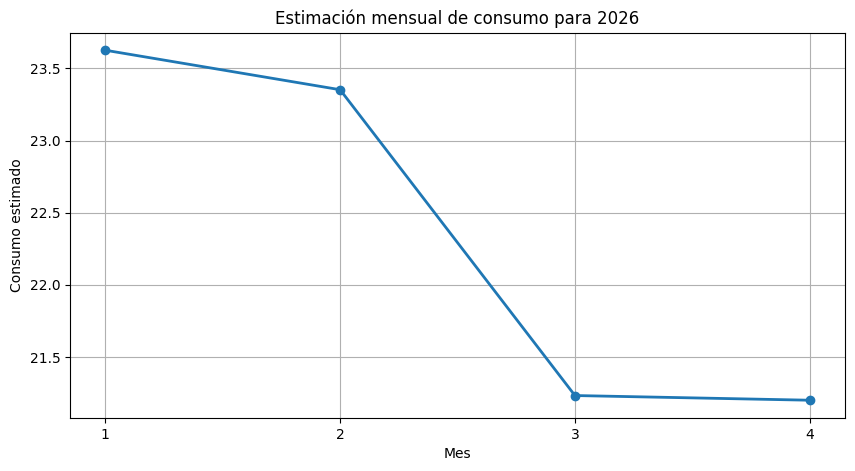

In [205]:
#visualizacion de la estimacion
plt.figure(figsize=(10,5))

plt.plot(df_pred_2026['mes'],df_pred_2026['consumo_estimado'], marker='o',linewidth=2)
plt.xticks(df_pred_2026['mes'])

plt.xlabel('Mes')
plt.ylabel('Consumo estimado')
plt.title('Estimación mensual de consumo para 2026')

plt.grid(True)
plt.show();

In [206]:
consumo_total = df_pred_2026['consumo_estimado'].sum()
consumo_promedio = df_pred_2026['consumo_estimado'].mean()

print(f'Consumo total estimado (ene-abr 2026): {consumo_total:,.2f}')
print(f'Consumo promedio mensual estimado: {consumo_promedio:,.2f}')

Consumo total estimado (ene-abr 2026): 89.41
Consumo promedio mensual estimado: 22.35


In [210]:
#CONSUMO ESTIMADO TOTAL POR MES 2026 - MODELO EMPRESA

df_est_empresa_cons_mes = (
    df_est_modelo_empresa[
        ["CONSUMO ESTIMADO ENERO",
         "CONSUMO ESTIMADO FEBRERO",
         "CONSUMO ESTIMADO MARZO",
         "CONSUMO ESTIMADO ABRIL"]
    ]
    .sum()
    .reset_index()
)

df_est_empresa_cons_mes.columns = ["MES", "CONSUMO"]

df_pred_2026_completo = df_pred_2026.copy()
df_pred_2026_completo["CONS EST EMPRESA"]= df_est_empresa_cons_mes["CONSUMO"].div(1e6)
df_pred_2026_completo["CONS TOT FIN"]=CONS_TOT_FIN_CORR_2026["CONSUMO TOTAL FINAL"]
df_pred_2026_completo["Delta Empresa vs CONS TOT FIN"]=(df_pred_2026_completo["CONS EST EMPRESA"]-df_pred_2026_completo["CONS TOT FIN"])
df_pred_2026_completo["Delta Empresa vs CONS TOT FIN (%)"]=(df_pred_2026_completo["Delta Empresa vs CONS TOT FIN"]/df_pred_2026_completo["CONS TOT FIN"])*100
df_pred_2026_completo["Delta Modelo 1 vs CONS TOT FIN"]=(df_pred_2026_completo["consumo_estimado"]-df_pred_2026_completo["CONS TOT FIN"])
df_pred_2026_completo["Delta Modelo 1 vs CONS TOT FIN (%)"]=(df_pred_2026_completo["Delta Modelo 1 vs CONS TOT FIN"]/df_pred_2026_completo["CONS TOT FIN"])*100

df_pred_2026_completo

,mes,hdd,cdd,consumo_estimado,CONS EST EMPRESA,CONS TOT FIN,Delta Empresa vs CONS TOT FIN,Delta Empresa vs CONS TOT FIN (%),Delta Modelo 1 vs CONS TOT FIN,Delta Modelo 1 vs CONS TOT FIN (%)
0,1,5.133199,0.266801,23.625723,24.031684,24.003720,0.027964,0.116497,-0.377997,-1.574744
1,2,5.122024,0.116369,23.352005,21.832529,20.712962,1.119567,5.405150,2.639043,12.741022
2,3,3.392339,0.421640,21.232628,21.806653,20.522687,1.283966,6.256325,0.709941,3.459300
3,4,1.340139,2.238611,21.200149,19.667545,18.237237,1.430308,7.842788,2.962912,16.246493


# **Gráficos, comparaciones y conclusiones**

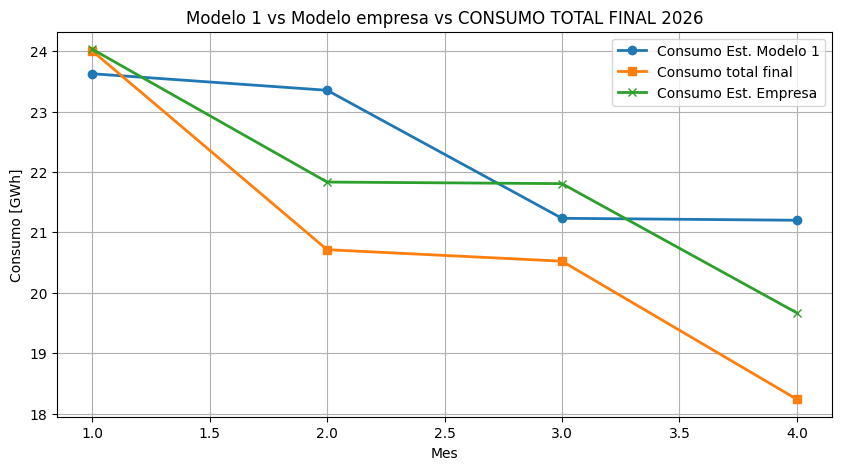

In [212]:
#Gráficos comparativos estimaciones y consumo total final


plt.figure(figsize=(10,5))
plt.plot(df_pred_2026_completo['mes'],df_pred_2026_completo['consumo_estimado'], marker='o',linewidth=2, label='Consumo Est. Modelo 1')
plt.plot(df_pred_2026_completo['mes'],df_pred_2026_completo['CONS TOT FIN'], marker='s',linewidth=2, label='Consumo total final')
plt.plot(df_pred_2026_completo['mes'],df_pred_2026_completo['CONS EST EMPRESA'], marker='x',linewidth=2, label='Consumo Est. Empresa')

plt.xlabel('Mes')
plt.ylabel('Consumo [GWh]')
plt.title('Modelo 1 vs Modelo empresa vs CONSUMO TOTAL FINAL 2026')

plt.grid(True)
plt.legend()

plt.show()

El primer dato interés a tener en cuenta es la precisión en la estimación por parte del modelo de la empresa con respecto al Consumo de Enero. En este mes, el modelo propuesto, estimó un 1.57% menos, lo que implica que, al menos en enero, el modelo de factor estacional es mucho más cercano al comportamiento real. Nótese lo siguiente: El factor estacional toma como parámetro la demanda, en términos de cómo varía con respecto al tiempo. La demanda también tiene un componente de pérdidas, el cual no es sólo influenciado por las variaciones en la temperatura sino por factores económicos y es posible apreciar aquí que el consumo estimado con el modelo de la empresa tuvo una diferencia relaivamente pequeña porcentualmente con respecto al consumo total final en el mes de enero.

Llevando el análisis más en profundidad, se pueden evaluar los betas e interpretar qué es lo que están contando en lo que se refiere al negocio de la energía, aplicado a este análisis:


$$
c(t) = B + \beta_c \cdot HDD(t) + \beta_f \cdot CDD(t)
$$



$$
\beta_f = \frac{\partial c}{\partial HDD(t)}
$$

$$
\beta_c = \frac{\partial c}{\partial CDD(t)}
$$

Interprétese lo siguiente:
$$
c(t) = 15.3351 \text{ GWh} + 1.5264 \frac{\text{ GWh}}{°C}\cdot \overline{HDD} + 1.7062 \frac{\text{ GWh}}{°C}\cdot \overline{CDD}
$$
$$
R^2 = 0.8572
$$

Esto quiere decir que el componente térmico explicó el 85.72% de la variabilidad en el consumo a lo largo de 12 meses para los clientes seleccionados, bajo el supuesto de que este segmento tarifario responde a la temperatura y no a factores económicos como sí es el caso de los clientes industriales, apartados del análisis desde el comienzo.

Si uno compara los betas y observa los gráficos de 2025, puede apreciar que el invierno incrementó significativamente el consumo...
excepto en el mes donde el aumento debió haber sido más significativo, teóricamente, partiendo de los supuestos mencionados: julio 2025.

A los fines de evaluar mejor variabilidad de consumo, también es conveniente dejar de lado el factor tiempo y pensar en variaciones de temperatura, lo cual introduce los siguientes gráficos:




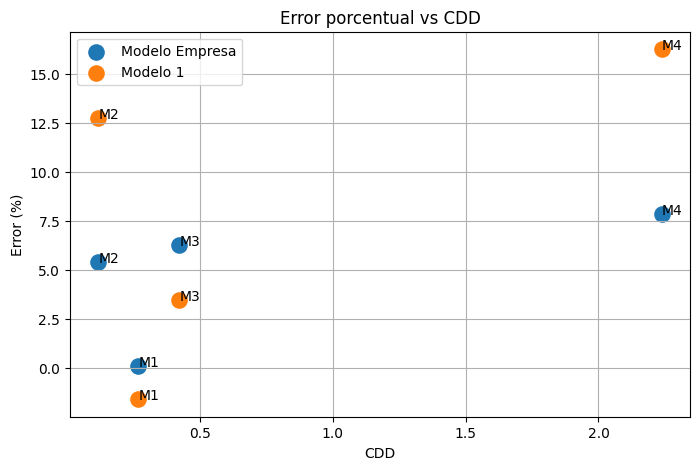

In [213]:
#Gráficos comparativos CDD

plt.figure(figsize=(8,5))

plt.scatter(
    df_pred_2026_completo["cdd"],
    df_pred_2026_completo["Delta Empresa vs CONS TOT FIN (%)"],
    s=120,
    label="Modelo Empresa"
)

plt.scatter(
    df_pred_2026_completo["cdd"],
    df_pred_2026_completo["Delta Modelo 1 vs CONS TOT FIN (%)"],
    s=120,
    label="Modelo 1"
)

for _, row in df_pred_2026_completo.iterrows():

    plt.annotate(
        f'M{int(row["mes"])}',
        (
            row["cdd"],
            row["Delta Empresa vs CONS TOT FIN (%)"]
        )
    )

    plt.annotate(
        f'M{int(row["mes"])}',
        (
            row["cdd"],
            row["Delta Modelo 1 vs CONS TOT FIN (%)"]
        )
    )

plt.xlabel("CDD")
plt.ylabel("Error (%)")
plt.title("Error porcentual vs CDD")
plt.grid(True)
plt.legend()

plt.show()

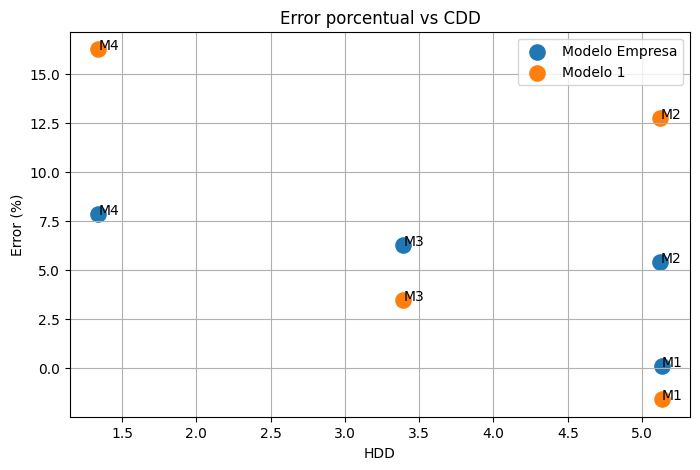

In [214]:
plt.figure(figsize=(8,5))

plt.scatter(
    df_pred_2026_completo["hdd"],
    df_pred_2026_completo["Delta Empresa vs CONS TOT FIN (%)"],
    s=120,
    label="Modelo Empresa"
)

plt.scatter(
    df_pred_2026_completo["hdd"],
    df_pred_2026_completo["Delta Modelo 1 vs CONS TOT FIN (%)"],
    s=120,
    label="Modelo 1"
)

for _, row in df_pred_2026_completo.iterrows():

    plt.annotate(
        f'M{int(row["mes"])}',
        (
            row["hdd"],
            row["Delta Empresa vs CONS TOT FIN (%)"]
        )
    )

    plt.annotate(
        f'M{int(row["mes"])}',
        (
            row["hdd"],
            row["Delta Modelo 1 vs CONS TOT FIN (%)"]
        )
    )

plt.xlabel("HDD")
plt.ylabel("Error (%)")
plt.title("Error porcentual vs CDD")
plt.grid(True)
plt.legend()

plt.show()

En base a lo anterior, se puede observar que hay una gran variabilidad no explicable por el modelo de propuesto. En adición, corroboraremos numéricamente que el modelo de la empresa sigue respondiendo mejor que un modelo pura y exclusivamente térmico:

In [ ]:
rmse_empresa = np.sqrt(
    (df_pred_2026_completo["Delta Empresa vs CONS TOT FIN"] ** 2).mean()
)

rmse_modelo = np.sqrt(
    (df_pred_2026_completo["Delta Modelo 1 vs CONS TOT FIN"] ** 2).mean()
)

print(f"RMSE Empresa: {rmse_empresa:,.0f} GWh")
print(f"RMSE Modelo 1: {rmse_modelo:,.0f} GWh")

RMSE Empresa: 1 kWh
RMSE Modelo 1: 2 kWh


In [217]:
mape_empresa = (
    df_pred_2026_completo["Delta Empresa vs CONS TOT FIN (%)"]
    .abs()
    .mean()
)

mape_modelo = (
    df_pred_2026_completo["Delta Modelo 1 vs CONS TOT FIN (%)"]
    .abs()
    .mean()
)

print(f"MAPE Empresa: {mape_empresa:.2f}%")
print(f"MAPE Modelo 1: {mape_modelo:.2f}%")

print(f"RMSE Empresa: {rmse_empresa:,.0f} GWh")
print(f"RMSE Modelo 1: {rmse_modelo:,.0f} GWh")

MAPE Empresa: 4.91%
MAPE Modelo 1: 8.51%
RMSE Empresa: 1 GWh
RMSE Modelo 1: 2 GWh


Se concluye que el modelo que utiliza la empresa, al considerar estacionalidad basada en comportamiento global de clientes, aun incluyendo pérdidas, presenta menor variabilidad que un modelo pura y exclusivamente sostenido bajo los supuestos planteados de dependencia exclusiva con respecto a la variación térmica. Sería una buena alternativa considerar un modelo que tenga en cuenta variaciones económicas, no obstante, requeriría de otro análisis con un alcance distinto.